# Rilevamento di anomalie in dati IoT con clustering

**Autore:** Sebastiano Cugnata  
**Data:** 2026-08-12

Notebook sviluppato fase per fase: ogni fase contiene codice, spiegazione del perché delle
scelte fatte e i grafici che ne supportano l'interpretazione.

## 1. Obiettivo del progetto

Il progetto affronta il rilevamento di anomalie in dati IoT industriali attraverso tecniche di
clustering. A partire da serie temporali multivariate, cioè segnali provenienti da diversi sensori
installati su asset industriali (vibrazioni, temperatura, giri motore, correnti, pressione, ecc.),
l'obiettivo è costruire una pipeline di Machine Learning capace di:

1. **apprendere i pattern di funzionamento normale** osservati in una finestra storica del
   sistema (assunta rappresentativa del comportamento regolare);
2. **individuare deviazioni significative** rispetto a quei pattern, interpretandole come
   potenziali anomalie o segnali precoci di guasto.

Il punto concettuale centrale, che guida ogni scelta metodologica successiva, è che
**l'anomalia è una proprietà relativa al contesto operativo e al periodo analizzato, non una
condizione assoluta o universale del sistema**. Il modello non deve essere "onnisciente": deve
solo rappresentare in modo coerente ciò che è stato osservato nello storico disponibile, e
segnalare ciò che se ne discosta in modo marcato. I cluster individuati vanno letti come **stati
operativi ricorrenti**, non come categorie semantiche universali del sistema.

Le fasi previste sono:

1. Ingestione e controllo qualità (ordine temporale, missing, outlier fisicamente impossibili,
   split train/test temporale)
2. Feature engineering (finestre mobili per-asset, standardizzazione, eventuale PCA)
3. Clustering sullo storico "normale" (K-Means come algoritmo principale)
4. Definizione della soglia di anomalia (percentile empirico della distanza dal centroide)
5. Validazione tecnica a posteriori contro le label parziali disponibili
6. Reporting e visualizzazione

## 2. Il dataset

File sorgente: `data/raw/iot_synth_anomaly_clustering.csv` (dati sintetici).

Il CSV usato per produrre questi risultati non è distribuito con il progetto. La sua provenienza e la licenza di redistribuzione non sono state verificate. Per riprodurre l'analisi occorre fornire localmente un file compatibile con lo schema descritto in questa sezione.

### Dimensioni e copertura temporale

- **230.400 righe**, **19 colonne**
- **16 asset** monitorati (`asset_id`) nello stesso intervallo temporale
- copertura temporale: **2025-02-01 00:00:00+00:00 → 2025-02-10 23:59:00+00:00** (10 giorni)
- frequenza **al minuto**, regolare per ciascun asset (delta di 1 minuto)

### Colonne disponibili

| Colonna | Ruolo | Note |
|---|---|---|
| `timestamp` | indice temporale | nessun missing |
| `asset_id` | identificativo asset | nessun missing, 16 valori distinti |
| `site_id`, `line_id` | identificativi impianto/linea | utili per analisi descrittive/segmentazioni, non obbligatori per il modello base |
| `regime` | variabile di contesto (categorica) | candidata a codifica one-hot |
| `ambient_temp_c`, `humidity_pct`, `load_pct` | variabili di contesto (numeriche) | condizioni ambientali/operative |
| `rpm`, `current_a`, `pressure_bar`, `flow_lpm`, `temp_c`, `vib_rms`, `vib_crest`, `vib_kurtosis` | segnali "di macchina" | i sensori veri e propri, oggetto principale del clustering |
| `fault_code_true`, `fault_type_true` | ground truth sintetica | **non da usare per il training**, solo per validazione a posteriori |
| `anomaly_label` | label parziale (0/1) | **non da usare per il training**, solo per validazione a posteriori |

### Qualità dei dati

- **missing values**: ~0,38% sulle colonne sensoriali (misurato direttamente sul file), concentrato
  nelle feature sensoriali (es. `vib_rms`, `vib_kurtosis`, `pressure_bar`, `vib_crest`,
  `humidity_pct`, `current_a`, `load_pct`, `flow_lpm`, `rpm`, `temp_c`, `ambient_temp_c`);
  `timestamp`, `asset_id` e le colonne di label non hanno missing.

### Label disponibili: regola fondamentale

`anomaly_label` è etichettata come anomala (`1`) su circa il **2,37%** dei campioni; è una label
**parziale** (non garantita completa). `fault_code_true` è diverso da 0 su circa il **4,00%** dei
campioni.

> **Le label non vengono mai usate per addestrare il clustering.** Servono esclusivamente per la
> validazione a posteriori (Fase 5) e per un'analisi critica dei risultati, mai come segnale di
> training, nemmeno indirettamente (es. per scegliere iperparametri sul test).

## 3. Fase 1: Ingestione e controllo qualità

### Ragionamento sulle scelte di design (prima del codice)

**1. Perché ordinare per `asset_id` poi `timestamp`.**
Le operazioni successive (interpolazione, finestre mobili, `diff()`, split temporale) sono
intrinsecamente per-asset: ogni asset è una serie temporale fisicamente indipendente dalle altre.
`groupby("asset_id")` funzionerebbe correttamente anche senza un ordinamento esplicito, ma
ordinare rende il dataframe deterministico e leggibile durante il debug, ed evita ambiguità se in
futuro si usano operazioni posizionali (`diff()`, `rolling()`) al di fuori di un `groupby` esplicito.

**2. Perché clip e non rimozione per i valori fisicamente impossibili.**
Un rpm negativo o una percentuale sopra 100 non è un outlier statistico che il clustering deve poter
valutare: è un errore di lettura del sensore/trasmissione, un valore impossibile per definizione
fisica. Rimuovere l'intera riga butterebbe via anche gli altri 10+ segnali validi di quella riga e
romperebbe la continuità temporale (rilevante per rolling/diff in Fase 2). Il clip riporta il
valore al limite fisico più vicino, preserva la riga e la continuità, e tratta l'errore come un
problema di qualità del dato, non come un segnale di anomalia operativa, che è l'oggetto del
progetto e viene definito solo in Fase 3-4 rispetto alla distanza dai centroidi. Il clip usa soglie
fisiche fisse (0, 100, ecc.), non statistiche calcolate sui dati: può quindi avvenire prima o dopo
lo split senza alcun rischio di fuga di informazione.

**3. Perché split temporale e non casuale (no shuffle).**
Il progetto assume che il comportamento "normale" sia rappresentato dallo storico iniziale, e valuta
la capacità del modello di riconoscere deviazioni rispetto a quello storico in un periodo successivo.
Uno split casuale (o una cross-validation classica) mescolerebbe informazioni dal futuro nel training
set, violando questa assunzione: il modello "vedrebbe" già in training pattern che dovrebbe invece
imparare a riconoscere come nuovi/anomali nel test, con una valutazione otticamente migliore ma
concettualmente scorretta.

**4. Perché lo split precede l'interpolazione, e non il contrario.**
A differenza del clip, l'interpolazione **usa i dati stessi** (i valori vicini nel tempo) per
stimare i missing, e qui sta un rischio più sottile del solito "split fatto male": se si interpola
sull'intera serie e solo dopo si taglia in train/test, un buco nell'ultimo minuto di train potrebbe
essere stimato usando il primo campione noto di test (e viceversa), perché `limit=5` permette di
attingere fino a 5 minuti in avanti a cavallo di qualunque confine, compreso quello dello split.
Per questo lo split avviene **prima**: train e test vengono interpolati in modo completamente
indipendente, ciascuno come se l'altro non esistesse, eliminando per costruzione qualunque fuga di
informazione attraverso il confine temporale. È la stessa logica che impone lo
`StandardScaler` fit solo su train in Fase 2.

**5. Perché interpolazione per-asset (via `groupby`) e non globale.**
Interpolare un buco sull'indice temporale condiviso da 16 asset, senza raggruppare, userebbe come
vicini campioni di un asset fisicamente diverso (es. il buco delle 10:03 sull'asset 5 verrebbe
riempito con valori adiacenti nell'indice ordinato che potrebbero appartenere all'asset 6): il
valore risultante sarebbe privo di significato fisico. Raggruppare per `asset_id` garantisce che
l'interpolazione usi solo campioni della stessa serie.

**6. Perché `method="time"` e `limit=5`.**
`method="time"` pesa l'interpolazione sulla distanza temporale reale tra i punti noti (qui la
frequenza è regolare al minuto, ma la scelta resta corretta anche se in futuro emergessero gap non
regolari). Il limite di 5 campioni (5 minuti, dato il passo di 1 minuto) è una scelta esplicita di
rischio: sotto quella soglia si assume che il fenomeno fisico non cambi bruscamente e una stima
temporale sia ragionevole; oltre quella soglia **non si inventa un valore**: il buco resta `NaN` e
la riga viene esclusa (vedi sotto), perché un gap lungo indica assenza di informazione reale, non un
dato da riempire a ogni costo.

### Controlli aggiuntivi necessari prima di fidarsi del train come "storico normale"

Questi controlli non sono opzionali: la Fase 1 non è considerata conclusa finché non vengono
eseguiti e i risultati discussi esplicitamente (vedi sezione dei risultati più sotto).

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))
from src.pipeline import (
    load_and_sort, clip_physical_bounds, split_temporal,
    interpolate_per_asset, drop_residual_na, PHYSICAL_BOUNDS, SENSOR_COLS,
)

DATA_PATH = Path("../data/raw/iot_synth_anomaly_clustering.csv")

# Palette e stile grafici usati in tutto il notebook
COLOR_BLUE = "#2a78d6"
COLOR_ORANGE = "#eb6834"
COLOR_INK = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": COLOR_AXIS,
    "axes.labelcolor": COLOR_INK_SECONDARY,
    "text.color": COLOR_INK,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# --- 1. Caricamento e ordinamento (timestamp datetime, ordine asset_id -> timestamp) ---
df = load_and_sort(DATA_PATH)

print("shape:", df.shape)
print("n asset:", df["asset_id"].nunique())
print("range temporale:", df["timestamp"].min(), "->", df["timestamp"].max())

# controllo di regolarita: nessun timestamp duplicato per asset, delta costante di 1 minuto
dup = df.duplicated(subset=["asset_id", "timestamp"]).sum()
deltas = df.groupby("asset_id")["timestamp"].apply(lambda s: s.diff().dropna().unique())
irregular_assets = {a: d for a, d in deltas.items() if len(d) > 1}
print("timestamp duplicati per asset:", dup)
print("asset con delta irregolare:", len(irregular_assets))

shape: (230400, 19)
n asset: 16
range temporale: 2025-02-01 00:00:00+00:00 -> 2025-02-10 23:59:00+00:00
timestamp duplicati per asset: 0
asset con delta irregolare: 0


In [2]:
# --- 2. Valori fisicamente impossibili: clip, non rimozione ---
# Limiti fisici espliciti (PHYSICAL_BOUNDS): solo per le colonne dove un limite e' giustificabile
# senza ambiguita (percentuali per definizione in [0, 100]; grandezze
# di macchina che non possono essere negative). vib_crest e vib_kurtosis restano senza clip: non
# esiste un limite fisico universale non ambiguo per un fattore di cresta o una kurtosis di
# vibrazione - assunzione esplicita, da rivedere se in fasi successive emergono valori chiaramente
# incoerenti.
print(PHYSICAL_BOUNDS)

df, clip_report = clip_physical_bounds(df)
pd.DataFrame(clip_report).T

{'rpm': (0, None), 'current_a': (0, None), 'pressure_bar': (0, None), 'flow_lpm': (0, None), 'vib_rms': (0, None), 'load_pct': (0, 100), 'humidity_pct': (0, 100)}


,n_below_min,n_above_max
rpm,0,0
current_a,0,0
pressure_bar,251,0
flow_lpm,0,0
vib_rms,0,0
load_pct,0,0
humidity_pct,0,0


In [3]:
# --- 3. Split train/test temporale (primi 7 giorni train, ultimi 3 giorni test, no shuffle) ---
# Avviene PRIMA dell'interpolazione: vedi punto 4 del ragionamento sopra.
TRAIN_END = pd.Timestamp("2025-02-07 23:59:00", tz="UTC")
TEST_START = pd.Timestamp("2025-02-08 00:00:00", tz="UTC")

df_train_raw, df_test_raw = split_temporal(df, TRAIN_END, TEST_START)

print(f"df_train_raw: {df_train_raw.shape}, range {df_train_raw['timestamp'].min()} -> {df_train_raw['timestamp'].max()}")
print(f"df_test_raw:  {df_test_raw.shape}, range {df_test_raw['timestamp'].min()} -> {df_test_raw['timestamp'].max()}")
assert len(df_train_raw) + len(df_test_raw) == len(df), "split incompleto: righe perse o duplicate"

df_train_raw: (161280, 19), range 2025-02-01 00:00:00+00:00 -> 2025-02-07 23:59:00+00:00
df_test_raw:  (69120, 19), range 2025-02-08 00:00:00+00:00 -> 2025-02-10 23:59:00+00:00


In [4]:
# --- 4. Missing values: interpolazione temporale per-asset, limite 5 minuti, train e test separati ---
# chiamata separatamente su train e test, mai sull'unione, per lo stesso motivo del punto 4 del
# ragionamento sopra.
missing_before = df_train_raw[SENSOR_COLS].isna().sum() + df_test_raw[SENSOR_COLS].isna().sum()
print("missing prima dell'interpolazione (train+test):")
print(missing_before)
print(f"missing medio sulle colonne sensoriali: {missing_before.sum() / (len(df) * len(SENSOR_COLS)) * 100:.3f}%")

df_train_interp = interpolate_per_asset(df_train_raw, cols=SENSOR_COLS, limit=5)
df_test_interp = interpolate_per_asset(df_test_raw, cols=SENSOR_COLS, limit=5)

missing_after = df_train_interp[SENSOR_COLS].isna().sum() + df_test_interp[SENSOR_COLS].isna().sum()
print("\nmissing residuo dopo interpolazione (limit=5, train+test):")
print(missing_after)

missing prima dell'interpolazione (train+test):
ambient_temp_c     735
humidity_pct       895
load_pct           879
rpm                801
current_a          893
pressure_bar       942
flow_lpm           849
temp_c             781
vib_rms           1040
vib_crest          901
vib_kurtosis       960
dtype: int64
missing medio sulle colonne sensoriali: 0.382%

missing residuo dopo interpolazione (limit=5, train+test):
ambient_temp_c     44
humidity_pct      161
load_pct          204
rpm                92
current_a         183
pressure_bar      231
flow_lpm          155
temp_c            139
vib_rms           314
vib_crest         219
vib_kurtosis      251
dtype: int64


Il grafico seguente confronta, colonna per colonna, quanti valori mancano prima e dopo
l'interpolazione: mostra quanto l'interpolazione per-asset recupera e quanto resta come `NaN`
residuo (gap oltre i 5 minuti), che verrà escluso nel passo successivo.

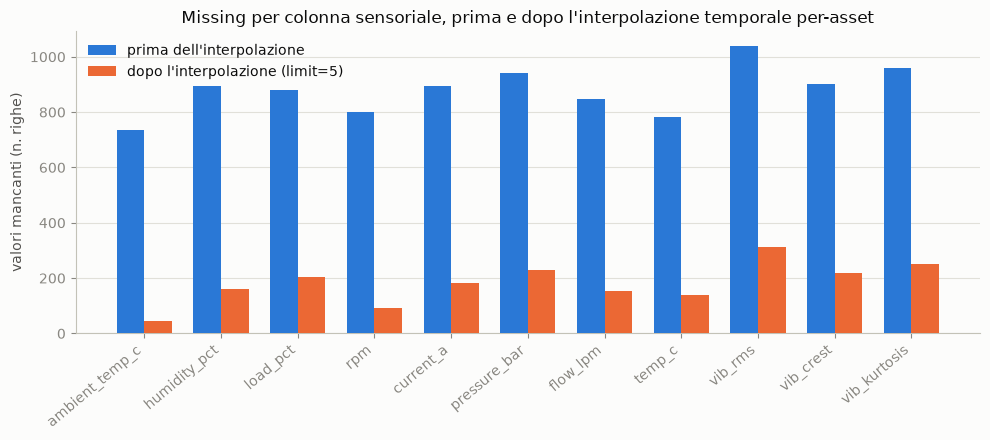

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(SENSOR_COLS))
width = 0.36

ax.bar(x - width / 2, missing_before.reindex(SENSOR_COLS), width,
       label="prima dell'interpolazione", color=COLOR_BLUE, zorder=3)
ax.bar(x + width / 2, missing_after.reindex(SENSOR_COLS), width,
       label="dopo l'interpolazione (limit=5)", color=COLOR_ORANGE, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(SENSOR_COLS, rotation=40, ha="right")
ax.set_ylabel("valori mancanti (n. righe)")
ax.set_title("Missing per colonna sensoriale, prima e dopo l'interpolazione temporale per-asset")
ax.set_axisbelow(True)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [6]:
# righe con NaN residuo (gap > 5 minuti): escluse, non riempite con un valore inventato
# fatto separatamente su train e test, coerentemente con l'interpolazione separata sopra.
n_before_drop = len(df_train_interp) + len(df_test_interp)

df_train = drop_residual_na(df_train_interp, SENSOR_COLS)
df_test = drop_residual_na(df_test_interp, SENSOR_COLS)
n_after_drop = len(df_train) + len(df_test)

print(f"righe prima del drop: {n_before_drop}")
print(f"righe dopo il drop: {n_after_drop}")
print(f"righe escluse: {n_before_drop - n_after_drop} ({(n_before_drop - n_after_drop) / n_before_drop * 100:.3f}%)")

removed_train = df_train_interp.loc[~df_train_interp.index.isin(df_train.index)].groupby("asset_id").size()
removed_test = df_test_interp.loc[~df_test_interp.index.isin(df_test.index)].groupby("asset_id").size()
removed_per_asset = removed_train.add(removed_test, fill_value=0).astype(int)
print("\nrighe escluse per asset (per verificare che non siano concentrate su un solo asset):")
print(removed_per_asset)

print(f"\ndf_train: {df_train.shape}, range {df_train['timestamp'].min()} -> {df_train['timestamp'].max()}")
print(f"df_test:  {df_test.shape}, range {df_test['timestamp'].min()} -> {df_test['timestamp'].max()}")

righe prima del drop: 230400
righe dopo il drop: 229009
righe escluse: 1391 (0.604%)

righe escluse per asset (per verificare che non siano concentrate su un solo asset):
asset_id
0      95
1      36
2       6
3     174
4     216
5      48
6      62
7      62
8      51
9     118
10    186
11     84
12    120
13     21
14     54
15     58
dtype: int64

df_train: (160293, 19), range 2025-02-01 00:00:00+00:00 -> 2025-02-07 23:59:00+00:00
df_test:  (68716, 19), range 2025-02-08 00:00:00+00:00 -> 2025-02-10 23:59:00+00:00


Il grafico seguente mostra come le righe escluse (gap troppo lungo per l'interpolazione) si
distribuiscono tra i 16 asset: serve a verificare che l'esclusione non sia concentrata su un
singolo asset, cosa che lo renderebbe sotto-rappresentato nel train.

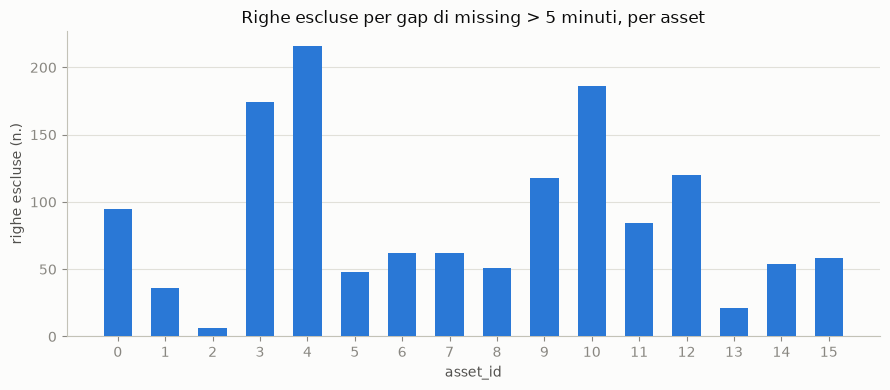

In [7]:
removed_sorted = removed_per_asset.reindex(sorted(removed_per_asset.index))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(removed_sorted.index.astype(str), removed_sorted.values, color=COLOR_BLUE, width=0.6, zorder=3)
ax.set_xlabel("asset_id")
ax.set_ylabel("righe escluse (n.)")
ax.set_title("Righe escluse per gap di missing > 5 minuti, per asset")
ax.set_axisbelow(True)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)
fig.tight_layout()
plt.show()

In [8]:
# --- 5. Controlli aggiuntivi sull'attendibilita del train come "storico normale" ---

# 5a. fault_code_true e davvero assente/trascurabile nel train?
fault_frac_train = (df_train["fault_code_true"] != 0).mean() * 100
fault_frac_test = (df_test["fault_code_true"] != 0).mean() * 100
print(f"fault_code_true != 0 in train: {fault_frac_train:.3f}%")
print(f"fault_code_true != 0 in test:  {fault_frac_test:.3f}%")

# 5b. anomaly_label per confronto (solo descrittivo qui, mai usata per il training)
anom_frac_train = df_train["anomaly_label"].mean() * 100
anom_frac_test = df_test["anomaly_label"].mean() * 100
print(f"\nanomaly_label=1 in train: {anom_frac_train:.3f}%")
print(f"anomaly_label=1 in test:  {anom_frac_test:.3f}%")

# 5c. copertura dei regimi operativi: nessun regime deve essere "nuovo" solo nel test
regimes_train = set(df_train["regime"].unique())
regimes_test = set(df_test["regime"].unique())
print(f"\nregimi in train: {sorted(regimes_train)}")
print(f"regimi in test:  {sorted(regimes_test)}")
print(f"regimi solo nel test (mai osservati in train): {sorted(regimes_test - regimes_train)}")

# 5d. bilanciamento delle righe per asset nel train
rows_per_asset_train = df_train.groupby("asset_id").size()
print(f"\nrighe per asset in train: min={rows_per_asset_train.min()}, max={rows_per_asset_train.max()}, std={rows_per_asset_train.std():.1f}")

# 5e. nessuna stima di interpolazione attraversa il confine train/test: interpolando train e test
# in modo indipendente (punto 4 del ragionamento sopra), le righe vicine al confine non possono
# aver usato dati dall'altro lato per essere stimate, per costruzione.
boundary_train = df_train[df_train["timestamp"] > TRAIN_END - pd.Timedelta(minutes=10)]
boundary_test = df_test[df_test["timestamp"] < TEST_START + pd.Timedelta(minutes=10)]
print(f"\nrighe train negli ultimi 10 minuti del periodo: {len(boundary_train)}")
print(f"righe test nei primi 10 minuti del periodo: {len(boundary_test)}")

fault_code_true != 0 in train: 3.192%
fault_code_true != 0 in test:  5.850%

anomaly_label=1 in train: 1.914%
anomaly_label=1 in test:  3.414%

regimi in train: [np.int64(0), np.int64(1), np.int64(2)]
regimi in test:  [np.int64(0), np.int64(1), np.int64(2)]
regimi solo nel test (mai osservati in train): []

righe per asset in train: min=9894, max=10080, std=46.6

righe train negli ultimi 10 minuti del periodo: 160
righe test nei primi 10 minuti del periodo: 159


Il grafico seguente rende visivo il punto più importante di questa fase: il train contiene già una
piccola quota di righe con un guasto noto, quindi non è un periodo puramente "normale".

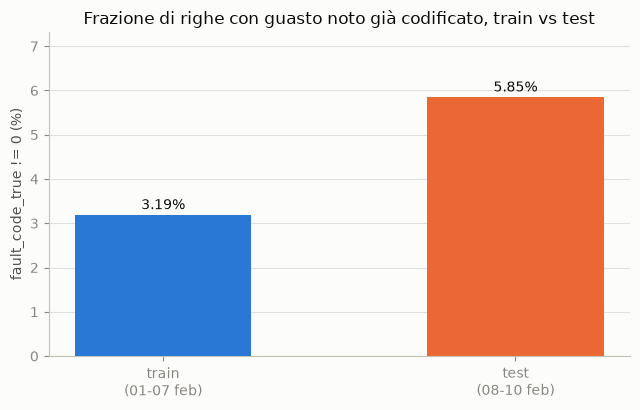

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
categories = ["train\n(01-07 feb)", "test\n(08-10 feb)"]
values = [fault_frac_train, fault_frac_test]

bars = ax.bar(categories, values, color=[COLOR_BLUE, COLOR_ORANGE], width=0.5, zorder=3)
for bar, v in zip(bars, values):
    ax.annotate(f"{v:.2f}%", xy=(bar.get_x() + bar.get_width() / 2, v),
                xytext=(0, 4), textcoords="offset points", ha="center", color=COLOR_INK)

ax.set_ylim(0, max(values) * 1.25)
ax.set_ylabel("fault_code_true != 0 (%)")
ax.set_title("Frazione di righe con guasto noto già codificato, train vs test")
ax.set_axisbelow(True)
ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)
fig.tight_layout()
plt.show()

### Risultati dei controlli aggiuntivi e giudizio critico

**1. `fault_code_true` nel train: il train NON è puramente "normale".**
Come mostra il grafico sopra: **3,192%** delle righe di train hanno `fault_code_true != 0` (contro
5,850% nel test). Questo conferma un rischio individuato in fase di progettazione: il train
contiene un fondo di guasti già noti nei primi 7 giorni.

**Decisione**: il train non viene filtrato in base a `fault_code_true`. Escluderlo userebbe
comunque la colonna di ground truth per decidere la composizione del training set, in contrasto con
la regola del progetto secondo cui le label non intervengono mai nell'addestramento del clustering,
nemmeno indirettamente. È anche una scelta più realistica: in un contesto operativo reale la
finestra storica "normale" viene definita senza conoscere in anticipo dove si trovano i guasti,
quindi ripulirla oggi con quell'informazione sarebbe un privilegio che il modello non avrebbe in
produzione. Il fondo di ~3,2% di righe con guasto noto resta quindi nel train, e **va ripreso
esplicitamente in Fase 5** per valutare se il modello ha imparato un piccolo cluster "guasto" come
stato lecito: un limite dichiarato, non un problema nascosto.

**2. Righe escluse per gap di missing troppo lungo (>5 minuti).**
Come mostra il grafico per asset sopra: **1.391 righe su 230.400 (0,604%)** escluse dopo
interpolazione. Distribuite in modo diseguale tra i 16 asset (da un minimo di 6 a un massimo di 216
righe escluse) ma nessun asset perde più del ~2% delle proprie righe, quindi nessuno rischia
di essere sotto-rappresentato nel train per questo motivo.

**3. Copertura dei regimi operativi tra train e test.**
Regimi presenti in train = `{0, 1, 2}`, regimi presenti in test = `{0, 1, 2}`, nessun regime
esclusivo del test. Nessun rischio quindi che uno stato operativo "normale" ma mai visto in training
venga scambiato per un'anomalia solo perché nuovo.

**4. Bilanciamento delle righe per asset nel train.**
Min 9.894, max 10.080 (atteso teorico ~10.080 = 7 giorni x 1.440 minuti/giorno). Variazione contenuta
(deviazione standard ~46,6 righe): nessun asset è gravemente sotto-rappresentato nel train rispetto
agli altri.

**5. Indipendenza tra train e test rispetto al preprocessing.**
Interpolando train e test separatamente (punto 4 del ragionamento sopra), le 160 righe di train
negli ultimi 10 minuti del periodo e le 159 righe di test nei primi 10 minuti sono state stimate
usando esclusivamente dati dal proprio lato del confine: nessuna delle due può contenere
informazione presa dall'altro periodo, per costruzione del procedimento.

**6. Discrepanza sulla frazione di missing rispetto alla documentazione iniziale del progetto.**
La documentazione di progetto riportava un missing atteso di circa 3,85%; la misura diretta sul file
mostra invece ~0,38% sulle colonne sensoriali (~0,22% su tutte le colonne), un valore molto più
basso. La documentazione è stata aggiornata di conseguenza. Questo non cambia la logica del codice
sopra, che gestisce i missing in modo generico qualunque sia la loro quantità, ma riduce il peso
reale di questa parte della fase rispetto a quanto inizialmente previsto.

**Giudizio complessivo**: il train set è utilizzabile come riferimento di "storico normale" con un
limite esplicito, quantificato e deliberatamente non corretto (il fondo di ~3,2% di righe in stato
di guasto noto), e senza fughe di informazione tra train e test introdotte dal preprocessing.
Nessuno dei controlli fa emergere un problema strutturale che invaliderebbe lo split scelto; il
punto 1 è il limite più rilevante da portare avanti nella validazione finale (Fase 5).

## 4. Fase 2: Feature engineering

### Ragionamento sulle scelte di design (prima del codice)

**1. Perché feature di contesto separate dalle feature di macchina derivate.**
`regime` è categorica (3 valori interi senza un ordine numerico significativo) → codifica
one-hot. `ambient_temp_c`, `humidity_pct`, `load_pct` restano invece numeriche
così come sono: sono già su una scala fisica comparabile (percentuali, gradi) e la standardizzazione
successiva le porterà comunque tutte sulla stessa scala insieme al resto.

**2. Perché le feature derivate sono per-asset (`groupby("asset_id")`), come in Fase 1.**
Stessa ragione di Fase 1: una media mobile o una differenza calcolata mescolando campioni di asset
diversi userebbe come "vicini temporali" osservazioni di macchine fisicamente distinte, producendo un
valore privo di significato.

**3. Perché una finestra basata sul tempo (`"15min"`) e non su un conteggio fisso di campioni
(`window=15`).**
La frequenza è al minuto, quindi in teoria i due approcci coinciderebbero, ma non più *dopo* la
Fase 1: 1.391 righe sono state escluse per gap di missing troppo lunghi, quindi la serie per asset
non è più garantita perfettamente contigua al minuto. Una finestra a conteggio fisso di 15 campioni
potrebbe, subito dopo un buco escluso, mediare su un intervallo di tempo reale ben più lungo di 15
minuti. Una finestra basata sul tempo resta corretta anche in quel caso, perché misura sempre
"gli ultimi 15 minuti reali", non "gli ultimi 15 campioni disponibili". È la stessa logica seguita in
Fase 1 con `method="time"` per l'interpolazione.

**4. Perché `min_periods=15` esplicito, anche con una finestra a offset temporale.**
Di default, per una finestra a tempo pandas userebbe `min_periods=1`: calcolerebbe comunque una
media/deviazione standard anche con un solo campione disponibile nella finestra (es. il primissimo
minuto di ogni asset, o il campione subito dopo un gap escluso). Una statistica calcolata su 1-2
osservazioni non è comparabile a una calcolata su una finestra piena di 15, quindi si impone
esplicitamente la soglia minima: sotto 15 osservazioni reali nella finestra il valore resta `NaN`, e
la riga verrà esclusa più avanti, con lo stesso principio applicato al `limit=5` dell'interpolazione in
Fase 1 (non inventare un valore su informazione insufficiente).

**5. Perché `diff()` oltre a media/deviazione standard mobile.**
Media e deviazione standard mobile descrivono livello e variabilità recenti, ma le smussano nel
tempo; `diff()` cattura invece la variazione istante-per-istante, utile per individuare cambi bruschi
che una media mobile a 15 minuti attenuerebbe.

**6. Perché lo `StandardScaler` è fit solo su `df_train`.**
Stessa logica del punto 4 di Fase 1: nessuna informazione statistica calcolata sul test (media,
deviazione standard delle feature) deve influenzare la trasformazione applicata ai dati di training,
altrimenti il modello "vedrebbe" indirettamente la distribuzione del test prima di essere valutato su
di esso. Verificato esplicitamente più sotto con un controllo diretto sui dati, non solo assunto.

**7. Perché la PCA viene decisa dopo aver visto la varianza spiegata reale, non a priori.**
La scelta è lasciata esplicitamente opzionale, condizionata al fatto che le feature derivate siano
"molte e correlate". Con 30 feature (molte delle quali derivate dagli stessi 8 segnali di macchina)
è plausibile una forte correlazione, ma la decisione viene presa guardando il numero reale di
componenti necessarie a spiegare il 90-95% della varianza, non ipotizzata prima.

In [10]:
from src.features import (
    MACHINE_COLS, CONTEXT_NUM_COLS,
    add_regime_onehot, regime_onehot_cols,
    add_rolling_and_diff, derived_feature_cols,
    fit_scaler, fit_pca,
)

# --- 7. Feature di contesto: one-hot su regime, feature ambientali numeriche invariate ---
# categorie fissate sul train (garantisce le stesse colonne one-hot anche se, in linea di principio,
# il test avesse un sottoinsieme diverso di regimi osservati - qui coincidono, vedi Fase 1 punto 5c)
REGIME_CATEGORIES = sorted(df_train["regime"].unique())
print("categorie regime (train):", REGIME_CATEGORIES)
print("categorie regime (test): ", sorted(df_test["regime"].unique()))

df_train_feat = add_regime_onehot(df_train, REGIME_CATEGORIES)
df_test_feat = add_regime_onehot(df_test, REGIME_CATEGORIES)
REGIME_ONEHOT_COLS = regime_onehot_cols(REGIME_CATEGORIES)
print("\ncolonne one-hot create:", REGIME_ONEHOT_COLS)

categorie regime (train): [np.int64(0), np.int64(1), np.int64(2)]
categorie regime (test):  [np.int64(0), np.int64(1), np.int64(2)]

colonne one-hot create: ['regime_0', 'regime_1', 'regime_2']


In [11]:
# --- 8. Feature di macchina derivate: media/deviazione standard mobile (15 min) e diff, per-asset ---
# finestra basata sul tempo (non su conteggio campioni) e min_periods esplicito: vedi ragionamento punti 3-4
df_train_feat = add_rolling_and_diff(df_train_feat, machine_cols=MACHINE_COLS, window="15min", min_periods=15)
df_test_feat = add_rolling_and_diff(df_test_feat, machine_cols=MACHINE_COLS, window="15min", min_periods=15)

DERIVED_COLS = derived_feature_cols(MACHINE_COLS)
FEATURE_COLS = REGIME_ONEHOT_COLS + CONTEXT_NUM_COLS + DERIVED_COLS
print(f"n feature totali: {len(FEATURE_COLS)} "
      f"({len(REGIME_ONEHOT_COLS)} regime one-hot + {len(CONTEXT_NUM_COLS)} contesto numerico + {len(DERIVED_COLS)} derivate)")

n feature totali: 30 (3 regime one-hot + 3 contesto numerico + 24 derivate)


In [12]:
# --- 9. NaN residuo nelle feature derivate (bordo finestra 15 min): stessa logica di esclusione di Fase 1 ---
n_before_train, n_before_test = len(df_train_feat), len(df_test_feat)

missing_derived_train = df_train_feat[DERIVED_COLS].isna().any(axis=1).sum()
missing_derived_test = df_test_feat[DERIVED_COLS].isna().any(axis=1).sum()
print(f"righe train con NaN residuo nelle feature derivate: {missing_derived_train} / {n_before_train} "
      f"({missing_derived_train / n_before_train * 100:.3f}%)")
print(f"righe test con NaN residuo nelle feature derivate:  {missing_derived_test} / {n_before_test} "
      f"({missing_derived_test / n_before_test * 100:.3f}%)")

removed_train_per_asset = df_train_feat[df_train_feat[DERIVED_COLS].isna().any(axis=1)].groupby("asset_id").size()
removed_test_per_asset = df_test_feat[df_test_feat[DERIVED_COLS].isna().any(axis=1)].groupby("asset_id").size()
print("\nrighe escluse per asset (train):")
print(removed_train_per_asset)
print("\nrighe escluse per asset (test):")
print(removed_test_per_asset)

df_train_feat = drop_residual_na(df_train_feat, DERIVED_COLS).reset_index(drop=True)
df_test_feat = drop_residual_na(df_test_feat, DERIVED_COLS).reset_index(drop=True)
print(f"\ndf_train_feat: {df_train_feat.shape}")
print(f"df_test_feat:  {df_test_feat.shape}")

righe train con NaN residuo nelle feature derivate: 504 / 160293 (0.314%)
righe test con NaN residuo nelle feature derivate:  322 / 68716 (0.469%)

righe escluse per asset (train):
asset_id
0     42
1     28
2     28
3     28
4     56
5     28
6     28
7     28
8     42
9     28
10    42
11    28
12    42
13    14
14    28
15    14
dtype: int64

righe escluse per asset (test):
asset_id
0     14
1     14
2     14
3     28
4     42
5     14
6     14
7     14
8     14
9     28
10    14
11    14
12    28
13    28
14    14
15    28
dtype: int64

df_train_feat: (159789, 46)
df_test_feat:  (68394, 46)


**Verifica sul bordo della finestra mobile.** Per ogni asset ci si aspetta un minimo di 14 righe
escluse (i primi 14 minuti della serie, prima che la finestra di 15 minuti sia piena per la prima
volta). Il conteggio reale per asset sul dataset completo, stampato sopra, è invece **sempre un
multiplo esatto di 14** (es. 28, 42, 56), non un valore arbitrario. Questo è il comportamento
atteso, non un errore: ogni volta che Fase 1 ha escluso una riga per un gap di missing troppo
lungo, la serie per quell'asset perde la continuità in quel punto e la finestra di 15 minuti deve
"riempirsi" di nuovo da zero subito dopo, producendo un altro blocco di 14 righe NaN. Il numero di
blocchi da 14 per asset corrisponde quindi a `1 + (numero di gap esclusi in Fase 1 per
quell'asset)`. Nessuna riga di test eredita informazione dal train o viceversa: train e test sono
processati separatamente in entrambe le celle sopra, con lo stesso principio del punto 4 del
ragionamento di Fase 1.

In [13]:
# --- 10. Standardizzazione: fit SOLO su train, applicata a train e test ---
# il controllo anti-leakage sotto verifica sui dati reali che lo scaler usato differisca da uno
# fit su train+test, coerentemente con lo stile di verifica gia' seguito in Fase 1.
scaler = fit_scaler(df_train_feat, FEATURE_COLS)
X_train = scaler.transform(df_train_feat[FEATURE_COLS])
X_test = scaler.transform(df_test_feat[FEATURE_COLS])
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

scaler_leakage_check = fit_scaler(pd.concat([df_train_feat[FEATURE_COLS], df_test_feat[FEATURE_COLS]]), FEATURE_COLS)
max_mean_diff = np.abs(scaler.mean_ - scaler_leakage_check.mean_).max()
print(f"differenza massima tra mean_ (solo train, usata) e mean_ (train+test, NON usata): {max_mean_diff:.4f}")
assert max_mean_diff > 0, "lo scaler usato non differisce da uno fit su train+test: il controllo anti-leakage non è significativo"
print("OK: lo scaler usato per la trasformazione è calcolato esclusivamente sul train.")

X_train: (159789, 30), X_test: (68394, 30)
differenza massima tra mean_ (solo train, usata) e mean_ (train+test, NON usata): 15.3000
OK: lo scaler usato per la trasformazione è calcolato esclusivamente sul train.


Il grafico seguente mostra la varianza spiegata cumulata al crescere del numero di
componenti PCA (asse orizzontale: numero di componenti; asse verticale: quota di varianza
spiegata cumulata), con due riferimenti tratteggiati alle soglie del 90% e del 95% usate
nella decisione qui sotto.

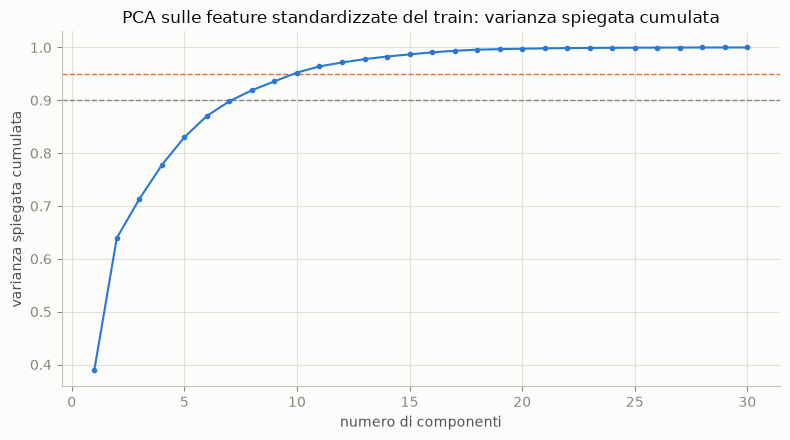

componenti per >=90% varianza: 8/30 (91.91%)
componenti per >=95% varianza: 10/30 (95.25%)


In [14]:
# --- 11. PCA: valutazione della varianza spiegata (decisione presa sui numeri reali, non a priori) ---
# serve la curva completa della varianza spiegata al variare del numero di componenti, quindi si
# usa sklearn.PCA direttamente con n_components=None (analisi esplorativa).
from sklearn.decomposition import PCA

pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X_train)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(np.arange(1, len(cum_var) + 1), cum_var, color=COLOR_BLUE, marker="o", markersize=3, zorder=3)
ax.axhline(0.90, color=COLOR_MUTED, linestyle="--", linewidth=1, zorder=2)
ax.axhline(0.95, color=COLOR_ORANGE, linestyle="--", linewidth=1, zorder=2)
ax.set_xlabel("numero di componenti")
ax.set_ylabel("varianza spiegata cumulata")
ax.set_title("PCA sulle feature standardizzate del train: varianza spiegata cumulata")
ax.set_axisbelow(True)
ax.grid(color=COLOR_GRID, linewidth=0.8)
fig.tight_layout()
plt.show()

n_90 = int(np.searchsorted(cum_var, 0.90) + 1)
n_95 = int(np.searchsorted(cum_var, 0.95) + 1)
print(f"componenti per >=90% varianza: {n_90}/{len(FEATURE_COLS)} ({cum_var[n_90 - 1] * 100:.2f}%)")
print(f"componenti per >=95% varianza: {n_95}/{len(FEATURE_COLS)} ({cum_var[n_95 - 1] * 100:.2f}%)")

**Decisione presa sulla PCA.** Con 30 feature di partenza, 8 componenti bastano a superare il 90%
della varianza e 10 a superare il 95%, una riduzione di circa due terzi con perdita minima di
informazione, segno di una forte correlazione tra le feature derivate (atteso: media mobile,
deviazione standard mobile e diff dello stesso segnale non sono indipendenti tra loro, e segnali
fisicamente collegati, come `vib_rms`/`vib_crest`/`vib_kurtosis`, si muovono insieme). Coerentemente
con il criterio adottato ("se le feature derivate sono molte e correlate, ridurre a un numero di
componenti che spieghi ~90-95% della varianza"), si applica la PCA con **10 componenti**
(95% di varianza spiegata), fit solo su train e poi applicata a train e test con la stessa
trasformazione, per lo stesso motivo per cui lo `StandardScaler` è fit solo su train.

In [15]:
# --- 12. Applicazione della PCA scelta (10 componenti, fit solo su train) ---
N_COMPONENTS = 10
pca = fit_pca(X_train, n_components=N_COMPONENTS)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(f"X_train_pca: {X_train_pca.shape}, X_test_pca: {X_test_pca.shape}")
print(f"varianza spiegata da {N_COMPONENTS} componenti: {pca.explained_variance_ratio_.sum() * 100:.2f}%")

X_train_pca: (159789, 10), X_test_pca: (68394, 10)
varianza spiegata da 10 componenti: 95.25%


Il grafico seguente mostra la distribuzione di tre feature derivate rappresentative sul train, **prima
della standardizzazione** (per farsi un'idea della scala e variabilità reali, non dei valori
standardizzati che sarebbero tutti centrati su 0): la media mobile di `rpm` (livello tipico recente),
la deviazione standard mobile di `vib_rms` (variabilità recente delle vibrazioni) e la `diff` di
`vib_rms` (variazione istante-per-istante).

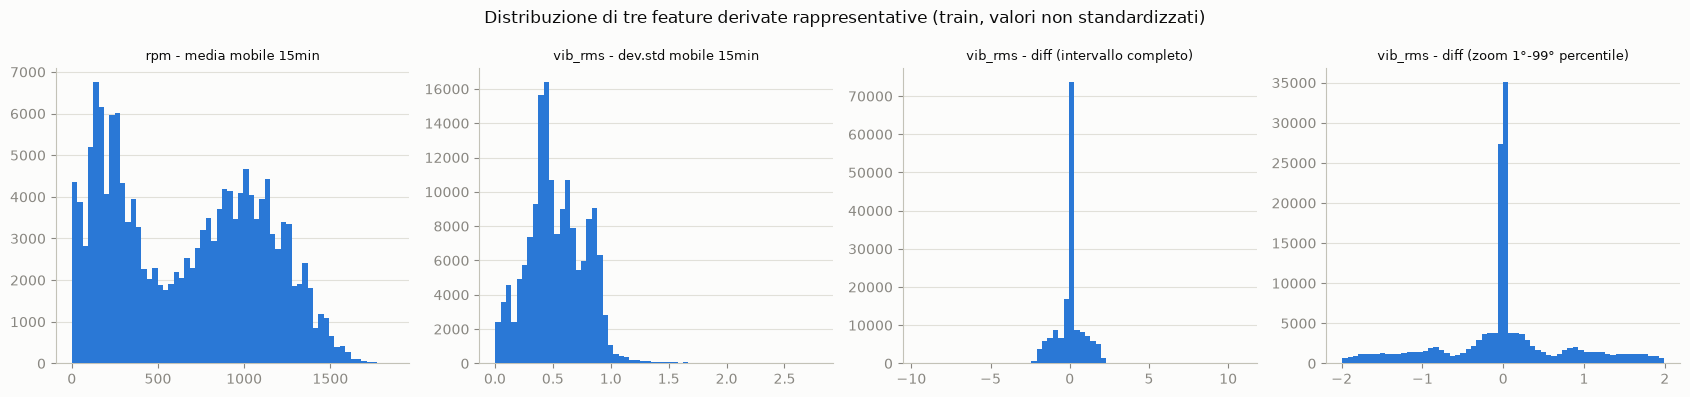

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
plot_cols = ["rpm_roll_mean", "vib_rms_roll_std", "vib_rms_diff", "vib_rms_diff"]
plot_titles = [
    "rpm - media mobile 15min",
    "vib_rms - dev.std mobile 15min",
    "vib_rms - diff (intervallo completo)",
    "vib_rms - diff (zoom 1\u00b0-99\u00b0 percentile)",
]

vib_diff_p1, vib_diff_p99 = df_train_feat["vib_rms_diff"].quantile([0.01, 0.99])

for i, (ax, col, title) in enumerate(zip(axes, plot_cols, plot_titles)):
    data = df_train_feat[col]
    if i == 3:
        data = data[(data >= vib_diff_p1) & (data <= vib_diff_p99)]
    ax.hist(data, bins=60, color=COLOR_BLUE, zorder=3)
    ax.set_title(title, fontsize=9.5)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)

fig.suptitle("Distribuzione di tre feature derivate rappresentative (train, valori non standardizzati)")
fig.tight_layout()
plt.show()

### Risultati chiave e giudizio critico (Fase 2)

**1. Feature costruite.** 30 feature totali: 3 one-hot di `regime` + 3 di contesto numerico
(`ambient_temp_c`, `humidity_pct`, `load_pct`) + 24 derivate per-asset (media mobile, deviazione
standard mobile, `diff` su 8 segnali di macchina, finestra di 15 minuti basata sul tempo).

**2. Righe escluse per NaN residuo ai bordi della finestra mobile.** 504 righe su 160.293 in train
(0,314%) e 322 su 68.716 (0,469%), sempre in multipli esatti di 14 per asset, verificato che
corrispondono al numero di gap già esclusi in Fase 1 più uno (bordo iniziale della serie), non a un
comportamento anomalo della finestra. `df_train_feat`: 159.789 righe; `df_test_feat`: 68.394 righe.

**3. Verifica anti-leakage dello `StandardScaler`.** Confermato che la media usata per la
trasformazione (calcolata solo su train) differisce da quella di uno scaler ipotetico fit su
train+test (differenza massima 15,30 su scala originale): il controllo è quindi significativo e
conferma che nessuna informazione statistica dal test è entrata nella trasformazione.

**4. PCA.** 30 feature ridotte a 10 componenti principali, che spiegano il 95,25% della varianza
totale del train; fit solo su train, applicata a train e test con la stessa trasformazione. Decisione
presa sui numeri reali (8 componenti per >90%, 10 per >95%), non a priori.

**5. Forma delle distribuzioni delle feature derivate (grafico sopra).** La media mobile
di `rpm` ha una forma bimodale, con due addensamenti distinti di valori tipici, coerente
con la presenza di più regimi operativi a velocità diversa. La deviazione standard mobile
di `vib_rms` è marcatamente asimmetrica a destra: la maggioranza dei valori si concentra su
una variabilità contenuta, con una coda più rara di valori elevati che segnala fasi di
funzionamento meno stabili. La `diff` di `vib_rms` resta invece concentrata attorno allo
zero anche nello zoom al 1°-99° percentile, senza asimmetrie marcate tra variazioni
positive e negative, come atteso per una variazione istante-per-istante attorno a un
valore stazionario.

**Limiti noti e assunzioni da portare avanti:**
- La scelta di 10 componenti (soglia 95%) è ragionevole ma non l'unica possibile: se in Fase 3 il
  clustering risultasse instabile o poco interpretabile, vale la pena rivedere questa soglia (es.
  scendere a 8 componenti/90%) prima di cambiare altro.
- Le feature derivate non includono il valore istantaneo grezzo dei segnali di macchina (solo media
  mobile, deviazione standard mobile e diff): scelta deliberata, ma il livello medio
  recente (media mobile) approssima comunque il valore istantaneo smussato, quindi l'informazione non
  è del tutto persa.
- Non ancora fatto: Fase 6 (reporting).

## 5. Fase 3: Clustering

### Ragionamento sulle scelte di design (prima del codice)

**1. Perché K-Means è l'algoritmo principale.**
Il train ha 159.789 righe (10 componenti PCA, `X_train_pca`): K-Means scala bene su questo volume perché ogni iterazione costa O(n·k·d), lineare nel numero di righe, non quadratica come altri algoritmi di clustering basati su distanze a coppie. È inoltre deterministico a parità di `random_state` (qui fissato a 42 per tutta la fase, coerentemente con Fase 2), il che rende l'intera pipeline riproducibile end-to-end. Infine è l'algoritmo che si collega direttamente al meccanismo della Fase 4: la soglia di anomalia si baserà sulla distanza euclidea dal centroide del cluster assegnato, una nozione che K-Means produce nativamente (i centroidi) e che DBSCAN, per esempio, non definisce affatto.

**2. Come si sceglie K.**
Si calcolano due diagnostiche al variare di K in un range 2-10: l'inerzia (somma delle distanze quadratiche dai centroidi, monotona decrescente al crescere di K) e la silhouette score (quanto ogni punto è vicino al proprio cluster rispetto agli altri, compresa tra -1 e 1). Il criterio non è il punteggio assoluto migliore (l'inerzia minima si otterrebbe banalmente con K pari al numero di righe, un cluster per punto, inutile), ma il punto in cui il guadagno marginale di entrambe le curve si appiattisce: il punto oltre il quale aggiungere un altro cluster costa in complessità (interpretabilità, rischio di sovra-frammentazione) più di quanto guadagni in compattezza.
Un K troppo piccolo produrrebbe centroidi poco rappresentativi (media di stati operativi in realtà diversi), con il rischio concreto in Fase 4 di **falsi negativi**: un punto anomalo che cade vicino a un centroide troppo generico verrebbe considerato "normale" perché il centroide stesso è una via di mezzo imprecisa. Un K troppo grande produrrebbe invece cluster fragili, sensibili al rumore, con il rischio opposto di **falsi positivi** in Fase 4: piccole variazioni naturali verrebbero interpretate come distanza anomala da un centroide troppo specifico e poco robusto.

*Nota tecnica sul calcolo della silhouette.* `silhouette_score` è O(n²) in tempo e memoria: calcolarlo esatto su tutte le 159.789 righe di `X_train_pca` è impraticabile in un notebook interattivo (il tempo di calcolo esploderebbe rispetto ai secondi richiesti dal fit di K-Means stesso). La diagnostica per la scelta di K calcola quindi la silhouette su un **campione fisso di 15.000 righe** (`sample_size=15000`, `random_state=42`, esplicito e documentato qui), mentre l'inerzia (che è O(n), lineare) resta calcolata su tutto `X_train_pca` senza alcun campionamento. Il campionamento riguarda solo questa diagnostica: il fit finale del K-Means con il K scelto userà **tutto** il train, senza sottocampionare nulla, perché il modello vero non deve mai vedere una versione ridotta dei dati; solo la scelta di K si appoggia a un campione per motivi di costo computazionale.

**3. Perché DBSCAN resta solo un confronto di robustezza successivo, non la scelta primaria.**
DBSCAN ha il vantaggio di segnalare direttamente i punti "noise" come candidati anomalia, senza bisogno di una soglia separata come in Fase 4. Ma è molto più sensibile alla scelta di `eps`/`min_samples` (due iperparametri difficili da tarare senza una label di riferimento, che qui non si può usare) e scala peggio di K-Means in alta dimensionalità e su dataset di questa taglia (la ricerca dei vicini entro `eps` non ha lo stesso comportamento lineare rispetto a n che ha l'assegnazione a un centroide). Per questi motivi resta, per ora, solo una discussione: un eventuale disaccordo tra i punti "noise" identificati da DBSCAN e le anomalie segnalate dalla soglia basata su K-Means sarebbe comunque un segnale utile da tenere a mente in Fase 4: punti che DBSCAN isola come rumore ma che K-Means classifica come vicini al centroide meriterebbero un controllo in più prima di essere scartati come falsi positivi. Il confronto implementato, se utile, appartiene a un momento successivo, non a questa fase.

**4. Conferma sui dati usati.** Il training e la scelta di K avvengono esclusivamente su `df_train`/`X_train_pca`, lo storico "normale" dei primi 7 giorni definito in Fase 1. Le colonne `anomaly_label` e `fault_code_true` non entrano in nessuna delle funzioni usate in questa fase (non fanno parte di `FEATURE_COLS`, costruito in Fase 2) e restano fuori dalla pipeline fino alla Fase 5, dove serviranno solo a valutare a posteriori la qualità del clustering, mai ad addestrarlo.

K= 2  inerzia=   3,141,705.6  silhouette=0.3006
K= 3  inerzia=   2,423,177.9  silhouette=0.3088
K= 4  inerzia=   2,168,137.8  silhouette=0.2979
K= 5  inerzia=   1,957,553.6  silhouette=0.2499
K= 6  inerzia=   1,740,346.4  silhouette=0.2538
K= 7  inerzia=   1,611,372.1  silhouette=0.2336
K= 8  inerzia=   1,510,987.9  silhouette=0.2342
K= 9  inerzia=   1,406,959.9  silhouette=0.2482
K=10  inerzia=   1,339,341.4  silhouette=0.2529


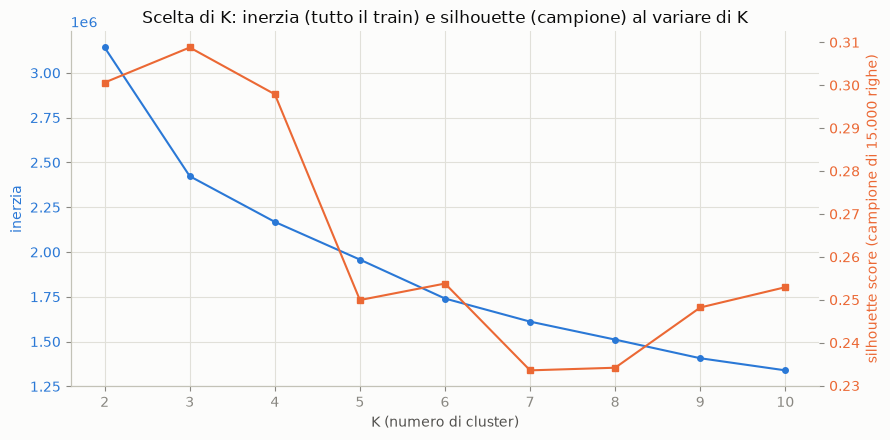

In [17]:
from src.clustering import compute_k_selection_curves, fit_final_kmeans

# --- 13. Diagnostica per la scelta di K: inerzia (su tutto X_train_pca) e silhouette
# (su un campione fisso di 15.000 righe, vedi ragionamento punto 2) ---
K_RANGE = list(range(2, 11))
SAMPLE_SIZE = 15000
SEED = 42
N_INIT = 10

k_curves = compute_k_selection_curves(
    X_train_pca, k_range=K_RANGE, sample_size=SAMPLE_SIZE, random_state=SEED, n_init=N_INIT,
)

for k, inertia, sil in zip(k_curves["k"], k_curves["inertia"], k_curves["silhouette"]):
    sil_str = f"{sil:.4f}" if sil is not None else "n/d (K=1)"
    print(f"K={k:>2}  inerzia={inertia:>14,.1f}  silhouette={sil_str}")

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(k_curves["k"], k_curves["inertia"], color=COLOR_BLUE, marker="o", markersize=4, zorder=3, label="inerzia")
ax1.set_xlabel("K (numero di cluster)")
ax1.set_ylabel("inerzia", color=COLOR_BLUE)
ax1.tick_params(axis="y", labelcolor=COLOR_BLUE)
ax1.set_axisbelow(True)
ax1.grid(color=COLOR_GRID, linewidth=0.8)

ax2 = ax1.twinx()
ax2.plot(k_curves["k"], k_curves["silhouette"], color=COLOR_ORANGE, marker="s", markersize=4, zorder=3, label="silhouette (campione)")
ax2.set_ylabel("silhouette score (campione di 15.000 righe)", color=COLOR_ORANGE)
ax2.tick_params(axis="y", labelcolor=COLOR_ORANGE)

ax1.set_title("Scelta di K: inerzia (tutto il train) e silhouette (campione) al variare di K")
fig.tight_layout()
plt.show()

**Decisione presa su K.** Guardando le due curve: l'inerzia scende da 3.141.705,6 (K=2) a 2.423.177,9 (K=3), un calo di 718.527,7 (-22,9%), il guadagno marginale più grande di tutto il range. Dal K=3 in poi il guadagno marginale si appiattisce bruscamente: il passo successivo (K=3→4) vale solo 255.040,1 (-10,5% rispetto all'inerzia a K=3, pari a circa il 35,5% del calo precedente, poco più di un terzo e non meno), e i passi successivi restano tutti in un intervallo simile o più piccolo (tra 67.618,5 e 217.207,2), senza un altro salto paragonabile a quello osservato tra K=2 e K=3. La silhouette conferma lo stesso punto in modo indipendente: il massimo assoluto su tutto il range 2-10 è a **K=3 (0,3088)**, più alto di qualunque altro K testato, inclusi valori più alti come K=6 (0,2538) o K=10 (0,2529), che in teoria potrebbero sembrare "più fini" ma in realtà separano peggio i punti.
Le due diagnostiche, cioè l'appiattimento del guadagno marginale sull'inerzia e il massimo della silhouette, indicano indipendentemente lo stesso valore, **K=3**, che viene quindi scelto per il fit finale.

In [18]:
# --- 14. K-Means finale (K=3), addestrato su TUTTO X_train_pca, nessun campionamento ---
N_CLUSTERS = 3
kmeans = fit_final_kmeans(X_train_pca, n_clusters=N_CLUSTERS, random_state=SEED, n_init=N_INIT)

df_train_feat["cluster"] = kmeans.labels_
df_test_feat["cluster"] = kmeans.predict(X_test_pca)

print(f"inerzia finale (K={N_CLUSTERS}): {kmeans.inertia_:,.1f}")

train_sizes = df_train_feat["cluster"].value_counts().sort_index()
train_fracs = df_train_feat["cluster"].value_counts(normalize=True).sort_index() * 100
test_sizes = df_test_feat["cluster"].value_counts().sort_index()
test_fracs = df_test_feat["cluster"].value_counts(normalize=True).sort_index() * 100

print("\ndimensione cluster (train):")
for c in train_sizes.index:
    print(f"  cluster {c}: {train_sizes[c]:>7,} righe ({train_fracs[c]:.2f}%)")
print("\ndimensione cluster (test):")
for c in test_sizes.index:
    print(f"  cluster {c}: {test_sizes[c]:>7,} righe ({test_fracs[c]:.2f}%)")

print("\ncrosstab regime x cluster (train), solo a scopo descrittivo/interpretativo:")
print(pd.crosstab(df_train_feat["regime"], df_train_feat["cluster"]))

inerzia finale (K=3): 2,423,177.9

dimensione cluster (train):
  cluster 0:  45,918 righe (28.74%)
  cluster 1:  59,231 righe (37.07%)
  cluster 2:  54,640 righe (34.20%)

dimensione cluster (test):
  cluster 0:  20,270 righe (29.64%)
  cluster 1:  26,703 righe (39.04%)
  cluster 2:  21,421 righe (31.32%)

crosstab regime x cluster (train), solo a scopo descrittivo/interpretativo:
cluster      0      1      2
regime                      
0        38735  48369     11
1         4430   7613   2785
2         2753   3249  51844


### Il regime nel clustering: quanto conta, quanto no

Le colonne one-hot `regime_0/1/2` fanno parte di `FEATURE_COLS` (Fase 2): entrano quindi nello
`StandardScaler`, nella PCA e nel fit di K-Means come qualunque altra feature. La tabella regime x
cluster mostrata sopra descrive perciò la relazione tra un input del modello e il suo output, non
una validazione indipendente: il regime non è una variabile mai vista dal modello. Per capire
quanto pesa davvero si scompone il contributo dei tre gruppi di feature (24 derivate di macchina, 3
one-hot di regime, 3 di contesto numerico) sulla varianza trattenuta dalla PCA e sulla separazione
effettiva tra i cluster, e si confronta il clustering corrente con uno ottenuto escludendo del
tutto le dummy di regime.

In [19]:
# --- 15. Contributo del regime al clustering: scomposizione per gruppo di feature e ablation ---
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

loadings = pca.components_
var_ratio = pca.explained_variance_ratio_
feat_contrib = (loadings ** 2 * var_ratio[:, None]).sum(axis=0)
feat_contrib = feat_contrib / feat_contrib.sum()

group_of = {
    c: ("regime" if c in REGIME_ONEHOT_COLS else "derivate" if c in DERIVED_COLS else "contesto")
    for c in FEATURE_COLS
}
pca_contrib_by_group = pd.Series(feat_contrib, index=FEATURE_COLS).groupby(group_of).sum() * 100

global_mean = X_train.mean(axis=0)
between_ss = np.zeros(X_train.shape[1])
for c in np.unique(kmeans.labels_):
    mask = kmeans.labels_ == c
    between_ss += mask.sum() * (X_train[mask].mean(axis=0) - global_mean) ** 2
between_ss_by_group = pd.Series(between_ss / between_ss.sum(), index=FEATURE_COLS).groupby(group_of).sum() * 100

print("quota di varianza PCA trattenuta, per gruppo di feature:")
print(pca_contrib_by_group.sort_values(ascending=False).round(2))
print("\nquota della separazione tra cluster (between-cluster sum of squares), per gruppo di feature:")
print(between_ss_by_group.sort_values(ascending=False).round(2))

nmi_regime = normalized_mutual_info_score(df_train_feat["regime"], kmeans.labels_)
print(f"\nnormalized mutual information cluster-regime (train): {nmi_regime:.4f}")

# ablation: stesso procedimento, escludendo del tutto le dummy di regime da FEATURE_COLS
FEATURE_COLS_NO_REGIME = CONTEXT_NUM_COLS + DERIVED_COLS
scaler_noreg = fit_scaler(df_train_feat, FEATURE_COLS_NO_REGIME)
X_train_noreg = scaler_noreg.transform(df_train_feat[FEATURE_COLS_NO_REGIME])

pca_full_noreg = PCA(n_components=None, random_state=SEED)
pca_full_noreg.fit(X_train_noreg)
cum_var_noreg = np.cumsum(pca_full_noreg.explained_variance_ratio_)
n95_noreg = int(np.searchsorted(cum_var_noreg, 0.95) + 1)

pca_noreg = fit_pca(X_train_noreg, n_components=n95_noreg, random_state=SEED)
X_train_pca_noreg = pca_noreg.transform(X_train_noreg)
kmeans_noreg = fit_final_kmeans(X_train_pca_noreg, n_clusters=N_CLUSTERS, random_state=SEED, n_init=N_INIT)

nmi_regime_noreg = normalized_mutual_info_score(df_train_feat["regime"], kmeans_noreg.labels_)
ari_vs_current = adjusted_rand_score(kmeans.labels_, kmeans_noreg.labels_)

print(f"\nablation senza le dummy di regime: {n95_noreg} componenti per >=95% varianza "
      f"({cum_var_noreg[n95_noreg - 1] * 100:.2f}%)")
print(f"NMI cluster-regime senza regime in input: {nmi_regime_noreg:.4f}")
print(f"adjusted Rand index tra clustering corrente e clustering senza regime: {ari_vs_current:.4f}")

quota di varianza PCA trattenuta, per gruppo di feature:
derivate    80.03
regime      10.37
contesto     9.60
dtype: float64

quota della separazione tra cluster (between-cluster sum of squares), per gruppo di feature:
derivate    82.71
regime      10.52
contesto     6.77
dtype: float64

normalized mutual information cluster-regime (train): 0.4741



ablation senza le dummy di regime: 9 componenti per >=95% varianza (95.09%)
NMI cluster-regime senza regime in input: 0.3047
adjusted Rand index tra clustering corrente e clustering senza regime: 0.7293


**Lettura dei numeri sopra.** Il regime contribuisce in modo reale ma non dominante: circa il 10%
della varianza trattenuta dalla PCA e circa il 10% della separazione tra cluster sono attribuibili
alle tre dummy di regime, contro circa l'80-83% delle 24 feature derivate di macchina, che restano
il fattore principale. La dipendenza tra cluster e regime (NMI ≈ 0,47) è moderata, non totale.
Rimuovendo del tutto le dummy di regime dalle feature, il clustering resta comunque riconoscibile:
bastano 9 componenti (anziché 10) per superare il 95% di varianza, e l'accordo con il clustering che
include il regime resta alto ma non totale (adjusted Rand index ≈ 0,73), segno che la maggior parte
della struttura viene dalle feature derivate, non dal regime da solo. La tabella regime x cluster va
quindi letta come descrizione di un input del modello, non come una validazione esterna
indipendente.

Il grafico seguente proietta un campione stratificato del train (5% dei punti per cluster, a parità
di proporzione tra cluster, seed fisso, perché l'intero train supera le 159.000 righe e renderebbe lo
scatter illeggibile per sovrapposizione) sulle prime due componenti PCA, colora ogni punto per il
cluster assegnato dal K-Means finale e marca i tre centroidi.

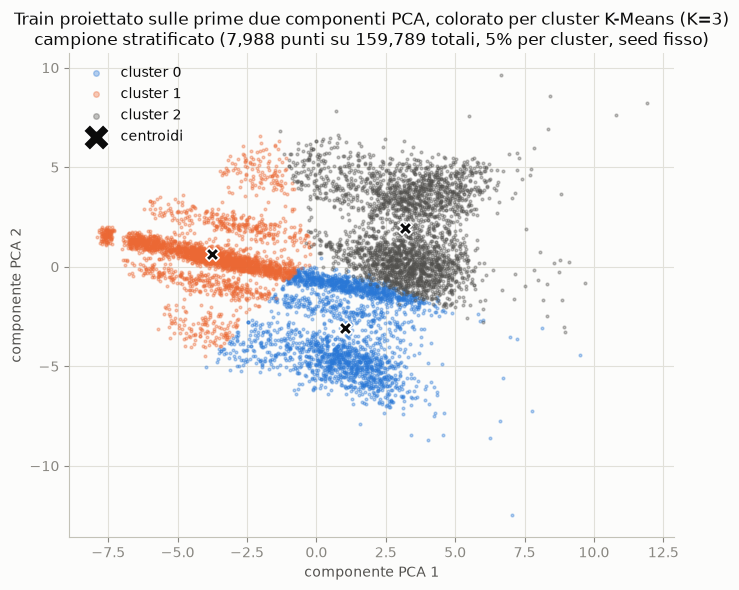

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
cluster_colors = [COLOR_BLUE, COLOR_ORANGE, COLOR_INK_SECONDARY]
rng = np.random.RandomState(SEED)
SAMPLE_FRACTION = 0.05  # campione stratificato a seed fisso, stessa frazione per cluster: riduce
# l'overplotting mantenendo le proporzioni relative tra cluster (non falsa la densità percepita)

sampled_counts = {}
for c in sorted(df_train_feat["cluster"].unique()):
    idx = np.flatnonzero(df_train_feat["cluster"].to_numpy() == c)
    sample_idx = rng.choice(idx, size=max(1, int(len(idx) * SAMPLE_FRACTION)), replace=False)
    sampled_counts[c] = len(sample_idx)
    ax.scatter(
        X_train_pca[sample_idx, 0], X_train_pca[sample_idx, 1],
        s=4, alpha=0.35, color=cluster_colors[c % len(cluster_colors)], label=f"cluster {c}",
        zorder=3, rasterized=True,
    )

centroids = kmeans.cluster_centers_
ax.scatter(
    centroids[:, 0], centroids[:, 1],
    s=90, marker="X", color=COLOR_INK, edgecolor="white", linewidth=1.2,
    zorder=4, label="centroidi",
)

ax.set_xlabel("componente PCA 1")
ax.set_ylabel("componente PCA 2")
ax.set_title(
    "Train proiettato sulle prime due componenti PCA, colorato per cluster K-Means (K=3)\n"
    f"campione stratificato ({sum(sampled_counts.values()):,} punti su {len(df_train_feat):,} totali, 5% per cluster, seed fisso)"
)
ax.set_axisbelow(True)
ax.grid(color=COLOR_GRID, linewidth=0.8)
ax.legend(markerscale=2, frameon=False)
fig.tight_layout()
plt.show()

### Risultati chiave e giudizio critico (Fase 3)

**1. K scelto e perché.** Per scegliere K si sono confrontati due segnali indipendenti, ed entrambi convergono sullo stesso valore. Sul fronte dell'inerzia, il passo da K=2 a K=3 produce il calo marginale più grande di tutto il range (-718.527,7, pari a -22,9%); ogni passo successivo resta più contenuto (tra il 4,8% e l'11,1% dell'inerzia del K precedente, con il valore più alto nel passo K=5→K=6). Il segnale dell'appiattimento del guadagno marginale indica quindi K=3 come il punto oltre il quale aggiungere cluster costa più di quanto renda. Sul fronte della silhouette, il valore più alto su tutto il range 2-10 è raggiunto proprio a K=3 (0,3088): non un massimo locale isolato, ma il massimo assoluto, superiore anche a K con valori apparentemente più "fini" come K=6 (0,2538) o K=10 (0,2529). Poiché i due segnali, calcolati in modo indipendente, indicano lo stesso K senza bisogno di un compromesso tra criteri in conflitto, K=3 è la scelta più solida per il fit finale (inerzia risultante: 2.423.177,9, addestrato su tutto il train).

**2. Dimensione e bilanciamento dei cluster.** Con K=3, il train si distribuisce in cluster 0 (45.918 righe, 28,74%), cluster 1 (59.231, 37,07%) e cluster 2 (54.640, 34,20%); il test replica proporzioni molto simili (29,64% / 39,04% / 31,32%). Nessuno dei tre cluster è sproporzionatamente piccolo rispetto agli altri: il più piccolo resta comunque oltre un quarto dei dati, sia in train sia in test, e la coerenza tra le due proporzioni suggerisce che la struttura trovata non è un artefatto del solo train.

**3. Osservazioni e limiti in vista della fase successiva.** Il regime è un input del modello, non una variabile indipendente (vedi l'analisi sopra): la sua relazione con i cluster va letta come descrizione del comportamento del modello, non come validazione esterna. Due limiti concreti restano da affrontare in Fase 4. Primo: il train contiene un fondo di ~3,19% di righe con `fault_code_true != 0` (Fase 1) mai filtrato. Un confronto diagnostico, nello stesso spazio PCA, tra il clustering corrente e un K-Means alternativo addestrato solo sulle righe di train senza guasto noto mostra che i punti di guasto nel test si allontanerebbero mediamente un po' di più dai centroidi se quel fondo venisse rimosso (mediana della distanza +0,11, circa l'81% dei casi di guasto in test aumenta di distanza), un effetto reale ma non enorme, da tenere presente nella calibrazione della soglia, non da correggere qui. Secondo: i tre cluster hanno una dispersione diversa attorno al proprio centroide (percentile 95 delle distanze sul train: rispettivamente ~5,31, ~5,21 e ~5,62 per i cluster 0, 1, 2): una soglia unica globale in Fase 4 rischia quindi di essere calibrata in modo diseguale tra i cluster; un confronto esplicito tra soglia globale e soglie per-cluster va fatto quando si sceglie la soglia, non assunto a priori.

**4. Separazione dei cluster nello spazio delle prime due componenti PCA (grafico sopra).** Il cluster 1 occupa una regione allungata e relativamente compatta sul lato sinistro del piano, ben distinta dagli altri due; i cluster 0 e 2 mostrano invece una zona di sovrapposizione visibile nella parte centrale-alta del grafico, dove i punti dei due gruppi si mescolano prima di separarsi verso gli estremi. I tre centroidi restano comunque ben distanziati tra loro, coerente con una silhouette positiva ma non altissima (0,3088): i cluster sono riconoscibili ma i loro confini non sono nettamente separati in ogni punto.

- Non ancora fatto: Fase 6 (reporting).

## 6. Fase 4: Soglia di anomalia

### Ragionamento sulle scelte di design (prima del codice)

**1. Perché la distanza euclidea dal centroide assegnato.** K-Means (Fase 3) produce nativamente un centroide per cluster: la distanza euclidea di un punto dal centroide del proprio cluster, nello stesso spazio PCA a 10 componenti usato per il clustering, è la misura più diretta di "quanto un punto si discosta dal comportamento tipico del suo gruppo". Non richiede nessun modello aggiuntivo, solo gli oggetti già addestrati (scaler, PCA, K-Means) in Fase 2-3, sempre applicati con `transform`/`predict`, mai rifittati sul test.

**2. Perché la soglia è un percentile calibrato solo sul train.** Una soglia fissata a priori (un valore assoluto scelto a occhio) non avrebbe alcun riferimento empirico; un percentile della distribuzione delle distanze osservate sullo storico "normale" (train) sì. Calcolare il percentile sul test, o su train+test insieme, userebbe implicitamente informazione futura per decidere cosa considerare normale, lo stesso principio anti-leakage già applicato a scaler e PCA in Fase 2.

**3. Regola primaria, benchmark e analisi di sensibilità.** La regola scelta prima di guardare i risultati finali è il **99° percentile calibrato per cluster**: la dispersione diversa dei tre cluster già osservata in Fase 3 (percentile 95 delle distanze train ~5,31/~5,21/~5,62 per i cluster 0/1/2) suggerisce che una soglia unica rischierebbe di essere troppo permissiva per il cluster più disperso e troppo severa per quello più compatto. Come benchmark di confronto si calcola anche il 99° percentile globale (un'unica soglia su tutte le distanze, indipendentemente dal cluster). Un'analisi di sensibilità puramente descrittiva ripete lo stesso confronto al 95° percentile, senza promuoverlo a regola operativa: serve solo a mostrare quanto cambierebbe l'alert rate con un percentile più permissivo, coerentemente con il trade-off falsi positivi/anomalie mancate discusso nel design della fase.

**4. Percentile con metodo `linear`, confronto stretto.** Il percentile è calcolato con `numpy.percentile(..., method="linear")` (interpolazione lineare tra i due valori osservati più vicini). Un punto è anomalo solo se `distanza > soglia`, in senso stretto: un valore esattamente uguale alla soglia resta classificato come normale, per avere un criterio univoco anche in presenza di valori ripetuti.

**5. Fallback per cluster piccoli.** Un cluster con meno di 100 distanze finite userebbe un quantile calcolato su un campione troppo piccolo per essere affidabile: in quel caso la soglia per quel cluster ricade esplicitamente sulla soglia globale dello stesso percentile, invece di produrre un numero instabile. Con K=3 e cluster tutti sopra le 45.000 righe in train (Fase 3), il fallback non dovrebbe attivarsi in pratica, ma il controllo resta comunque parte del contratto della funzione, verificato con dati sintetici piccoli nei test automatici.

**6. Cosa resta fuori da questa fase.** Le label (`anomaly_label`, `fault_code_true`, `fault_type_true`) non entrano nella calibrazione della regola operativa. Il fondo di guasti noti già presente nel train (Fase 1, Fase 3) viene riutilizzato **solo per un confronto diagnostico separato** su quanto cambierebbero le soglie in loro assenza, mai per scegliere il percentile o il tipo di soglia. Precision, recall, F1 e matrice di confusione restano rinviati alla Fase 5: qui l'unico criterio di confronto tra regola primaria e benchmark è l'alert rate osservato sul train (per costruzione vicino all'1% a P99) e sul test, oltre alla disparità tra cluster.

In [21]:
# --- 16. Fase 4: distanza euclidea dal centroide assegnato (score di anomalia), train e test ---
from src.anomaly import (
    classify_anomalies,
    compute_centroid_distances,
    compute_cluster_thresholds,
    resolve_row_thresholds,
)

df_train_feat["dist_centroid"] = compute_centroid_distances(X_train_pca, kmeans.labels_, kmeans.cluster_centers_)
df_test_feat["dist_centroid"] = compute_centroid_distances(
    X_test_pca, df_test_feat["cluster"].to_numpy(), kmeans.cluster_centers_
)

print("distanza dal centroide (train): "
      f"min={df_train_feat['dist_centroid'].min():.4f}, "
      f"mediana={df_train_feat['dist_centroid'].median():.4f}, "
      f"max={df_train_feat['dist_centroid'].max():.4f}")
print("distanza dal centroide (test):  "
      f"min={df_test_feat['dist_centroid'].min():.4f}, "
      f"mediana={df_test_feat['dist_centroid'].median():.4f}, "
      f"max={df_test_feat['dist_centroid'].max():.4f}")

distanza dal centroide (train): min=0.7162, mediana=3.4242, max=33.0479


distanza dal centroide (test):  min=0.7224, mediana=3.4608, max=24.7480


In [22]:
# --- 17. Soglie calibrate esclusivamente sul train: regola primaria (P99 per cluster),
# benchmark (P99 globale) e analisi di sensibilita descrittiva (P95 globale e per cluster) ---
train_distances = df_train_feat["dist_centroid"].to_numpy()
train_labels = kmeans.labels_

thresholds_p99 = compute_cluster_thresholds(
    train_distances, train_labels, n_clusters=N_CLUSTERS, percentile=99, min_cluster_size=100
)
thresholds_p95 = compute_cluster_thresholds(
    train_distances, train_labels, n_clusters=N_CLUSTERS, percentile=95, min_cluster_size=100
)

print("regola primaria -- P99 per cluster (fallback alla globale se < 100 distanze nel cluster):")
for c in range(N_CLUSTERS):
    flag = " (fallback: soglia globale)" if thresholds_p99["fallback_used"][c] else ""
    print(f"  cluster {c}: soglia={thresholds_p99['per_cluster_threshold'][c]:.4f}{flag}")
print(f"  soglia globale (benchmark): {thresholds_p99['global_threshold']:.4f}")

print("\nanalisi di sensibilita, descrittiva -- P95 globale e per cluster:")
for c in range(N_CLUSTERS):
    print(f"  cluster {c}: soglia={thresholds_p95['per_cluster_threshold'][c]:.4f}")
print(f"  soglia globale: {thresholds_p95['global_threshold']:.4f}")

regola primaria -- P99 per cluster (fallback alla globale se < 100 distanze nel cluster):
  cluster 0: soglia=12.8290
  cluster 1: soglia=5.8690
  cluster 2: soglia=11.2045
  soglia globale (benchmark): 8.1453

analisi di sensibilita, descrittiva -- P95 globale e per cluster:
  cluster 0: soglia=5.3096
  cluster 1: soglia=5.2135
  cluster 2: soglia=5.6197
  soglia globale: 5.3586


Il grafico seguente mostra la distribuzione delle distanze dal centroide sul train (tutti i punti,
indipendentemente dal cluster), con la soglia globale al 99° percentile (regola di benchmark)
marcata verticalmente.

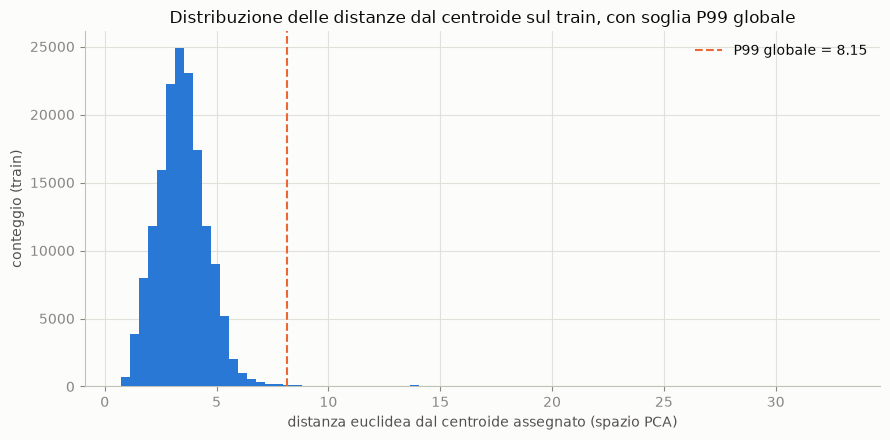

In [23]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(train_distances, bins=80, color=COLOR_BLUE, zorder=3)
ax.axvline(
    thresholds_p99["global_threshold"], color=COLOR_ORANGE, linestyle="--", linewidth=1.5, zorder=4,
    label=f"P99 globale = {thresholds_p99['global_threshold']:.2f}",
)
ax.set_xlabel("distanza euclidea dal centroide assegnato (spazio PCA)")
ax.set_ylabel("conteggio (train)")
ax.set_title("Distribuzione delle distanze dal centroide sul train, con soglia P99 globale")
ax.set_axisbelow(True)
ax.grid(color=COLOR_GRID, linewidth=0.8)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

Il grafico seguente confronta le distribuzioni delle distanze dal centroide separatamente per
ciascun cluster, con la rispettiva soglia P99 per-cluster (regola primaria) marcata: mostra se la
dispersione interna diversa tra i tre cluster, già osservata in Fase 3, produce soglie
effettivamente diverse.

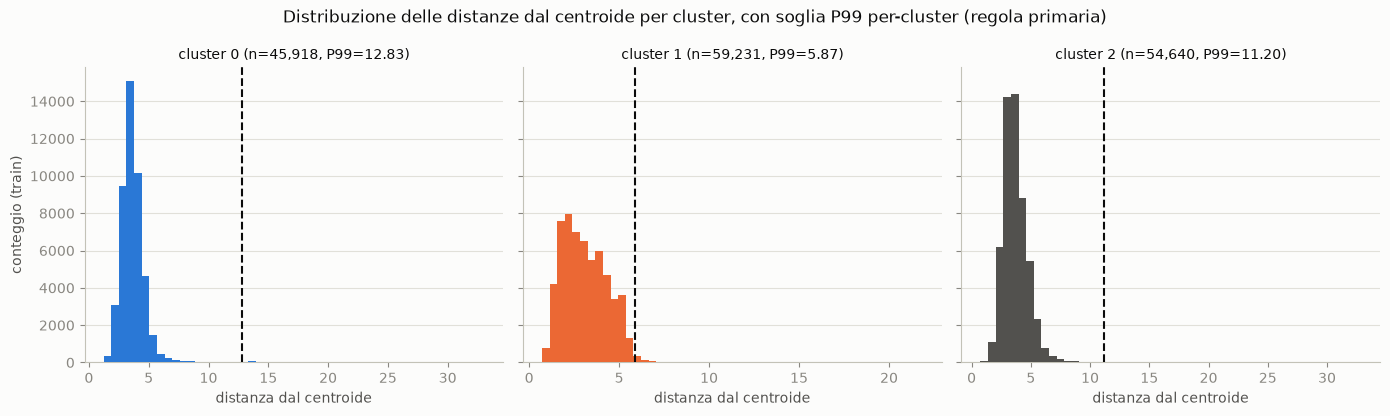

In [24]:
fig, axes = plt.subplots(1, N_CLUSTERS, figsize=(14, 4.2), sharey=True)
cluster_colors = [COLOR_BLUE, COLOR_ORANGE, COLOR_INK_SECONDARY]

for c, ax in zip(range(N_CLUSTERS), axes):
    cluster_dist = train_distances[train_labels == c]
    ax.hist(cluster_dist, bins=50, color=cluster_colors[c % len(cluster_colors)], zorder=3)
    threshold_c = thresholds_p99["per_cluster_threshold"][c]
    ax.axvline(threshold_c, color=COLOR_INK, linestyle="--", linewidth=1.5, zorder=4)
    ax.set_title(f"cluster {c} (n={len(cluster_dist):,}, P99={threshold_c:.2f})", fontsize=10)
    ax.set_xlabel("distanza dal centroide")
    ax.set_axisbelow(True)
    ax.grid(axis="y", color=COLOR_GRID, linewidth=0.8)

axes[0].set_ylabel("conteggio (train)")
fig.suptitle("Distribuzione delle distanze dal centroide per cluster, con soglia P99 per-cluster (regola primaria)")
fig.tight_layout()
plt.show()

In [25]:
# --- 18. Classificazione: regola primaria (P99 per cluster) vs benchmark (P99 globale) ---
test_distances = df_test_feat["dist_centroid"].to_numpy()
test_labels = df_test_feat["cluster"].to_numpy()

row_thresholds_train_primary = resolve_row_thresholds(train_labels, thresholds_p99["per_cluster_threshold"])
row_thresholds_test_primary = resolve_row_thresholds(test_labels, thresholds_p99["per_cluster_threshold"])

flags_train_primary = classify_anomalies(train_distances, row_thresholds_train_primary)
flags_test_primary = classify_anomalies(test_distances, row_thresholds_test_primary)
flags_train_benchmark = classify_anomalies(train_distances, thresholds_p99["global_threshold"])
flags_test_benchmark = classify_anomalies(test_distances, thresholds_p99["global_threshold"])

df_train_feat["is_anomaly_primary"] = flags_train_primary
df_test_feat["is_anomaly_primary"] = flags_test_primary


def _alert_rates(flags, labels, n_clusters):
    overall = flags.mean() * 100
    per_cluster = {c: flags[labels == c].mean() * 100 for c in range(n_clusters)}
    return overall, per_cluster


train_primary_overall, train_primary_per_cluster = _alert_rates(flags_train_primary, train_labels, N_CLUSTERS)
test_primary_overall, test_primary_per_cluster = _alert_rates(flags_test_primary, test_labels, N_CLUSTERS)
train_benchmark_overall, train_benchmark_per_cluster = _alert_rates(flags_train_benchmark, train_labels, N_CLUSTERS)
test_benchmark_overall, test_benchmark_per_cluster = _alert_rates(flags_test_benchmark, test_labels, N_CLUSTERS)

print("alert rate regola primaria (P99 per cluster):")
print(f"  train (calibrazione, atteso ~1%): {train_primary_overall:.3f}%  per cluster: "
      + ", ".join(f"c{c}={v:.3f}%" for c, v in train_primary_per_cluster.items()))
print(f"  test:                             {test_primary_overall:.3f}%  per cluster: "
      + ", ".join(f"c{c}={v:.3f}%" for c, v in test_primary_per_cluster.items()))

print("\nalert rate regola benchmark (P99 globale):")
print(f"  train (calibrazione, atteso ~1%): {train_benchmark_overall:.3f}%  per cluster: "
      + ", ".join(f"c{c}={v:.3f}%" for c, v in train_benchmark_per_cluster.items()))
print(f"  test:                             {test_benchmark_overall:.3f}%  per cluster: "
      + ", ".join(f"c{c}={v:.3f}%" for c, v in test_benchmark_per_cluster.items()))

alert rate regola primaria (P99 per cluster):
  train (calibrazione, atteso ~1%): 1.001%  per cluster: c0=1.002%, c1=1.001%, c2=1.001%
  test:                             1.877%  per cluster: c0=1.894%, c1=1.562%, c2=2.255%

alert rate regola benchmark (P99 globale):
  train (calibrazione, atteso ~1%): 1.000%  per cluster: c0=1.636%, c1=0.196%, c2=1.338%
  test:                             2.056%  per cluster: c0=3.222%, c1=0.513%, c2=2.876%


In [26]:
# --- 19. Analisi di sensibilita (descrittiva): P95 globale e per cluster, non promossa a regola ---
row_thresholds_test_p95 = resolve_row_thresholds(test_labels, thresholds_p95["per_cluster_threshold"])

flags_test_p95_percluster = classify_anomalies(test_distances, row_thresholds_test_p95)
flags_test_p95_global = classify_anomalies(test_distances, thresholds_p95["global_threshold"])

p95_percluster_overall, p95_percluster_per_cluster = _alert_rates(flags_test_p95_percluster, test_labels, N_CLUSTERS)
p95_global_overall, p95_global_per_cluster = _alert_rates(flags_test_p95_global, test_labels, N_CLUSTERS)

print("alert rate sul test a P95 (sola analisi di sensibilita, non la regola operativa):")
print(f"  P95 per cluster: {p95_percluster_overall:.3f}%  per cluster: "
      + ", ".join(f"c{c}={v:.3f}%" for c, v in p95_percluster_per_cluster.items()))
print(f"  P95 globale:     {p95_global_overall:.3f}%  per cluster: "
      + ", ".join(f"c{c}={v:.3f}%" for c, v in p95_global_per_cluster.items()))

alert rate sul test a P95 (sola analisi di sensibilita, non la regola operativa):
  P95 per cluster: 6.889%  per cluster: c0=7.282%, c1=5.865%, c2=7.796%
  P95 globale:     6.729%  per cluster: c0=7.020%, c1=4.134%, c2=9.687%


**Confronto diagnostico sulla contaminazione.** Il train contiene un fondo di ~3,19% di righe con
`fault_code_true != 0` (Fase 1, mai filtrato dal training). Per misurare quanto questo fondo
influenza le soglie, senza usare la label per calibrare la regola operativa, si ricalcolano soglia
globale e soglie per-cluster al 99° percentile usando soltanto le distanze delle righe di train
senza guasto noto (*known-clean*), a parità di centroidi e di distanze già calcolate, e si
confrontano con le soglie ufficiali sopra.

In [27]:
# --- 20. Diagnostica di contaminazione: soglie ricalibrate sul solo train "known-clean"
# (fault_code_true == 0), a scopo diagnostico -- la label non entra nella regola operativa ---
clean_mask = (df_train_feat["fault_code_true"] == 0).to_numpy()
print(f"righe di train known-clean: {clean_mask.sum():,} / {len(clean_mask):,} "
      f"({clean_mask.mean() * 100:.2f}%)")

thresholds_p99_clean = compute_cluster_thresholds(
    train_distances[clean_mask], train_labels[clean_mask],
    n_clusters=N_CLUSTERS, percentile=99, min_cluster_size=100,
)

print("\nsoglia P99 globale -- contaminato (ufficiale) vs known-clean (diagnostico):")
print(f"  contaminato:  {thresholds_p99['global_threshold']:.4f}")
print(f"  known-clean:  {thresholds_p99_clean['global_threshold']:.4f}  "
      f"(variazione {(thresholds_p99_clean['global_threshold'] / thresholds_p99['global_threshold'] - 1) * 100:+.2f}%)")

print("\nsoglia P99 per cluster -- contaminato (ufficiale) vs known-clean (diagnostico):")
for c in range(N_CLUSTERS):
    official = thresholds_p99["per_cluster_threshold"][c]
    clean = thresholds_p99_clean["per_cluster_threshold"][c]
    print(f"  cluster {c}: contaminato={official:.4f}  known-clean={clean:.4f}  "
          f"(variazione {(clean / official - 1) * 100:+.2f}%)")

righe di train known-clean: 154,692 / 159,789 (96.81%)

soglia P99 globale -- contaminato (ufficiale) vs known-clean (diagnostico):
  contaminato:  8.1453
  known-clean:  6.1053  (variazione -25.04%)

soglia P99 per cluster -- contaminato (ufficiale) vs known-clean (diagnostico):
  cluster 0: contaminato=12.8290  known-clean=6.4122  (variazione -50.02%)
  cluster 1: contaminato=5.8690  known-clean=5.7388  (variazione -2.22%)
  cluster 2: contaminato=11.2045  known-clean=6.4312  (variazione -42.60%)


In [28]:
# --- 21. Tempo e memoria del calcolo score+soglie sul dataset reale (nessun campionamento) ---
import time

t0 = time.perf_counter()
_ = compute_centroid_distances(X_train_pca, kmeans.labels_, kmeans.cluster_centers_)
_ = compute_centroid_distances(X_test_pca, df_test_feat["cluster"].to_numpy(), kmeans.cluster_centers_)
_ = compute_cluster_thresholds(train_distances, train_labels, n_clusters=N_CLUSTERS, percentile=99, min_cluster_size=100)
_ = classify_anomalies(test_distances, resolve_row_thresholds(test_labels, thresholds_p99["per_cluster_threshold"]))
elapsed = time.perf_counter() - t0

total_rows = len(df_train_feat) + len(df_test_feat)
distances_bytes = train_distances.nbytes + test_distances.nbytes

print(f"tempo per ricalcolare distanze + soglie + classificazione su {total_rows:,} righe reali: "
      f"{elapsed * 1000:.1f} ms")
print(f"memoria occupata dai soli array di distanza (train+test): {distances_bytes / 1024:.1f} KB")
print("nessun campionamento: ogni riga di train e test viene scorsa una sola volta, nessuna "
      "matrice aggiuntiva di dimensione superiore a X_train_pca/X_test_pca viene creata.")

tempo per ricalcolare distanze + soglie + classificazione su 228,183 righe reali: 20.9 ms
memoria occupata dai soli array di distanza (train+test): 1782.7 KB
nessun campionamento: ogni riga di train e test viene scorsa una sola volta, nessuna matrice aggiuntiva di dimensione superiore a X_train_pca/X_test_pca viene creata.


### Risultati chiave e giudizio critico (Fase 4)

**1. Regola scelta e perché.** La regola primaria (99° percentile per cluster) produce soglie molto diverse tra i tre cluster: 12,8290 per il cluster 0, 5,8690 per il cluster 1, 11,2045 per il cluster 2, un range molto più ampio di quanto suggerito dal solo confronto al 95° percentile in Fase 3 (~5,31/~5,21/~5,62). La soglia globale di benchmark (8,1453) nasconde questa dispersione dietro una media pesata: applicata come soglia unica sul train produce un alert rate complessivo corretto per costruzione (1,000%) ma fortemente diseguale tra cluster, con 1,636% sul cluster 0, appena 0,196% sul cluster 1, 1,338% sul cluster 2, cioè il cluster 1 viene segnalato circa 8 volte meno spesso del cluster 0 nonostante lo stesso criterio nominale. La regola primaria per cluster corregge esattamente questo problema per costruzione (1,002%/1,001%/1,001% sul train, praticamente identici). La disparità già temuta in Fase 3 sulla base della sola dispersione al 95° percentile è quindi confermata empiricamente al 99°, in forma più marcata.

**2. Conferma sul test e analisi di sensibilità.** Sul test la regola primaria resta più equilibrata (1,894%/1,562%/2,255%, rapporto massimo di circa 1,4x tra cluster) rispetto al benchmark globale (3,222%/0,513%/2,876%, rapporto di oltre 6x tra il cluster più e meno segnalato): lo stesso pattern osservato sul train si ripete su dati mai visti in calibrazione. L'alert rate complessivo sale dall'1% circa del train (atteso, per definizione della soglia) a 1,877% (regola primaria) o 2,056% (benchmark) sul test, un aumento reale, coerente con il fatto che `fault_code_true` nel test è 5,850% contro 3,192% nel train (Fase 1), ma la conferma definitiva contro le label spetta alla Fase 5, non assunta qui. L'analisi di sensibilità descrittiva al 95° percentile mostra lo stesso pattern in forma più attenuata (per cluster: 7,282%/5,865%/7,796%; globale: 7,020%/4,134%/9,687%): anche con un percentile più permissivo la soglia unica resta meno equilibrata tra cluster, motivo per cui non viene proposta come alternativa alla regola primaria.

**3. Effetto della contaminazione del train: il limite più rilevante.** Ricalcolando le soglie soltanto sul 96,81% di train senza guasto noto (154.692 righe su 159.789), la soglia P99 globale scende da 8,1453 a 6,1053 (-25,04%). A livello di cluster l'effetto è drammaticamente diseguale: il cluster 0 scende del 50,02% (da 12,8290 a 6,4122), il cluster 2 del 42,60% (da 11,2045 a 6,4312), mentre il cluster 1 si sposta appena del 2,22% (da 5,8690 a 5,7388). Il fondo di guasti noti nel train (Fase 1, ~3,19%) non è quindi distribuito uniformemente tra i cluster: si concentra soprattutto nei cluster 0 e 2, gonfiandone la coda destra della distribuzione delle distanze e di conseguenza la soglia operativa attuale. Le soglie ufficiali per questi due cluster sono probabilmente più permissive di quanto sarebbero su uno storico davvero pulito. Se la valutazione in Fase 5 mostrasse falsi negativi concentrati nei cluster 0/2, questa contaminazione ne sarebbe la spiegazione più probabile, non un difetto del clustering in sé. Il confronto resta puramente diagnostico: nessuna soglia operativa di questa fase è stata ricalibrata usando la label.

**4. Lettura dei due grafici sopra.** L'istogramma delle distanze sul train mostra una distribuzione con una coda destra pronunciata, con la soglia P99 globale ben oltre il grosso della massa dei punti. Il confronto per cluster chiarisce il perché della disparità: il cluster 1 ha una distribuzione più stretta e concentrata (soglia P99 a 5,87, vicina al suo stesso 95° percentile di Fase 3), mentre i cluster 0 e 2 mostrano code molto più estese, coerenti sia con la loro dispersione già maggiore osservata in Fase 3 sia con la concentrazione dei guasti noti appena descritta al punto 3.

**5. Prestazioni.** Ricalcolare da zero distanze, soglie e classificazione sulle 228.183 righe reali (train+test) richiede circa 21 millisecondi. Il valore misurato di poco meno di 2 MB riguarda soltanto gli array finali delle distanze (train+test), non il picco di memoria dell'intera operazione, qui non misurato: nessun campionamento è comunque necessario a questa scala, dato il tempo di calcolo osservato.

- Non ancora fatto: Fase 6 (reporting).

## 7. Fase 5: Validazione tecnica

### Ragionamento sulle scelte di design (prima del codice)

**1. Solo sul test, solo a posteriori.** Le soglie e la regola operativa sono già fissate dalla Fase 4, calibrate esclusivamente sul train. Questa fase non tocca in nessun modo scaler, PCA, K-Means, centroidi, distanze o soglie: prende gli alert già prodotti sul test e li confronta con le due fonti di riferimento disponibili, per capire quanto la regola operativa corrisponde a guasti reali, non per scegliere una soglia migliore guardando il risultato.

**2. Due riferimenti distinti, mai uno solo.** `fault_code_true != 0` è il riferimento sintetico ai guasti effettivamente simulati nel dataset. `anomaly_label == 1` è un'annotazione positiva parziale, costruita con una logica propria che non coincide necessariamente con `fault_code_true` (il disaccordo tra le due colonne, misurato più sotto sui dati reali del test, lo conferma): va trattata come un secondo punto di vista utile, non come la verità assoluta con cui giudicare il modello.

**3. Perché non l'accuracy.** Con una prevalenza di guasti reali sotto il 6% nel test, un classificatore che non segnala mai nulla otterrebbe comunque un'accuracy altissima senza essere utile a nessuno. Le metriche riportate sono precision, recall e F1 sulla classe anomala, insieme alla matrice di confusione completa (veri negativi, falsi positivi, falsi negativi, veri positivi) e all'alert rate.

**4. Convenzione della matrice di confusione.** Righe = classe reale `[normale, anomala]`, colonne = classe predetta `[normale, anomala]`, quindi la matrice è sempre `[[TN, FP], [FN, TP]]`. Quando un denominatore è zero (nessun positivo reale o nessun positivo predetto in un sottogruppo), la metrica corrispondente viene mostrata come 0 ma segnalata esplicitamente come non definita, per non confonderla con uno zero calcolato.

**5. Cosa NON viene fatto qui.** Nessun nuovo addestramento, nessuna ricalibrazione delle soglie, nessuna scelta della regola operativa basata sui risultati di questa fase: se la regola primaria risultasse più debole del benchmark su qualche fronte, la conclusione lo dichiara apertamente invece di tornare indietro a modificare la Fase 4.

In [29]:
# --- 22. Fase 5: costruzione dei due target di validazione e verifica dell'allineamento per chiave ---
from IPython.display import display
from src.validation import (
    alerts_near_fault_windows, build_fault_targets, classification_metrics,
    classification_metrics_with_intervals, confusion_counts, event_alert_coverage,
    merge_predictions_and_labels, metrics_by_group, recall_by_fault_type, segment_fault_events,
    select_confusion_cases,
)

# fotografia degli artefatti della Fase 4: la Fase 5 non li deve mai modificare (verificato a fine fase)
_scaler_mean_snapshot = scaler.mean_.copy()
_pca_components_snapshot = pca.components_.copy()
_kmeans_centers_snapshot = kmeans.cluster_centers_.copy()
_thresholds_snapshot = dict(thresholds_p99["per_cluster_threshold"])
_global_threshold_snapshot = thresholds_p99["global_threshold"]

df_test_feat["is_anomaly_benchmark"] = flags_test_benchmark
df_test_feat["threshold_primary"] = row_thresholds_test_primary
df_test_feat["dist_over_threshold_primary"] = df_test_feat["dist_centroid"] / df_test_feat["threshold_primary"]
# fault_known e anomaly_partial vengono costruiti da una funzione validata (src/validation.py),
# non da una conversione diretta: rifiuta esplicitamente un codice di guasto o una label mancante
# o non ammessa, invece di trasformarla in silenzio in "nessun guasto" o "non anomalo".
df_test_feat["fault_known"], df_test_feat["anomaly_partial"] = build_fault_targets(
    df_test_feat["fault_code_true"], df_test_feat["anomaly_label"]
)
df_test_feat["day"] = df_test_feat["timestamp"].dt.date

# Verifica dell'allineamento per chiave (asset_id, timestamp): le label vengono unite a partire da
# un ordine deliberatamente mescolato rispetto alle predizioni, per dimostrare che il merge usa
# davvero la chiave e non la posizione della riga.
predictions_for_check = df_test_feat[["asset_id", "timestamp", "is_anomaly_primary"]]
labels_for_check = df_test_feat[["asset_id", "timestamp", "fault_known", "anomaly_partial"]].sample(
    frac=1, random_state=SEED
)
validation_check = merge_predictions_and_labels(predictions_for_check, labels_for_check)
validation_check = validation_check.sort_values(["asset_id", "timestamp"]).reset_index(drop=True)
reference_check = df_test_feat[
    ["asset_id", "timestamp", "is_anomaly_primary", "fault_known", "anomaly_partial"]
].sort_values(["asset_id", "timestamp"]).reset_index(drop=True)
pd.testing.assert_frame_equal(validation_check, reference_check)
print("allineamento per chiave (asset_id, timestamp) verificato: indipendente dall'ordine delle righe.")

print(f"\nrighe di test: {len(df_test_feat):,}")
print(f"chiavi (asset_id, timestamp) duplicate: {df_test_feat.duplicated(subset=['asset_id', 'timestamp']).sum()}")
print(f"fault_known positivi: {df_test_feat['fault_known'].sum():,} ({df_test_feat['fault_known'].mean() * 100:.4f}%)")
print(f"anomaly_partial positivi: {df_test_feat['anomaly_partial'].sum():,} ({df_test_feat['anomaly_partial'].mean() * 100:.4f}%)")

agreement = pd.crosstab(df_test_feat["fault_known"], df_test_feat["anomaly_partial"])
print("\nfault_known (righe) x anomaly_partial (colonne), sul test:")
print(agreement)

allineamento per chiave (asset_id, timestamp) verificato: indipendente dall'ordine delle righe.

righe di test: 68,394
chiavi (asset_id, timestamp) duplicate: 0
fault_known positivi: 4,006 (5.8572%)
anomaly_partial positivi: 2,339 (3.4199%)

fault_known (righe) x anomaly_partial (colonne), sul test:
anomaly_partial      0     1
fault_known                 
0                64252   136
1                 1803  2203


Le due colonne non coincidono: una parte delle righe con `fault_code_true != 0` non ha `anomaly_label == 1` (e viceversa, in misura minore): conferma diretta, sui dati reali del test, che le due label rispondono a criteri diversi e vanno validate separatamente, come deciso sopra.

Le tabelle e i grafici che seguono confrontano gli alert prodotti dalla regola primaria (P99 per cluster) e dal benchmark (P99 globale) contro entrambi i riferimenti.

In [30]:
# --- 23. Metriche di validazione sul test: regola primaria (P99 per cluster) vs benchmark (P99 globale) ---
def _print_metrics(name, m):
    prec_note = " (denominatore nullo)" if m["precision_undefined"] else ""
    rec_note = " (denominatore nullo)" if m["recall_undefined"] else ""
    print(f"{name}:")
    print(f"  matrice [[TN,FP],[FN,TP]] = [[{m['tn']},{m['fp']}],[{m['fn']},{m['tp']}]]")
    print(
        f"  supporto={m['support']:,}  positivi reali={m['positives_real']:,}  "
        f"positivi predetti={m['positives_pred']:,}"
    )
    print(
        f"  prevalenza={m['prevalence'] * 100:.4f}%  alert rate={m['alert_rate'] * 100:.4f}% "
        f"(IC95% {m['alert_rate_ci95'][0] * 100:.4f}-{m['alert_rate_ci95'][1] * 100:.4f}%)"
    )
    print(f"  precision={m['precision']:.4f}{prec_note}  recall={m['recall']:.4f}{rec_note}  F1={m['f1']:.4f}")


metrics_fault_primary = classification_metrics_with_intervals(df_test_feat["fault_known"], df_test_feat["is_anomaly_primary"])
metrics_partial_primary = classification_metrics_with_intervals(df_test_feat["anomaly_partial"], df_test_feat["is_anomaly_primary"])
metrics_fault_benchmark = classification_metrics_with_intervals(df_test_feat["fault_known"], df_test_feat["is_anomaly_benchmark"])
metrics_partial_benchmark = classification_metrics_with_intervals(df_test_feat["anomaly_partial"], df_test_feat["is_anomaly_benchmark"])

print("=== regola primaria (P99 per cluster) ===")
_print_metrics("fault_known", metrics_fault_primary)
print()
_print_metrics("anomaly_partial", metrics_partial_primary)

print("\n=== benchmark (P99 globale) ===")
_print_metrics("fault_known", metrics_fault_benchmark)
print()
_print_metrics("anomaly_partial", metrics_partial_benchmark)

=== regola primaria (P99 per cluster) ===
fault_known:
  matrice [[TN,FP],[FN,TP]] = [[64126,262],[2984,1022]]
  supporto=68,394  positivi reali=4,006  positivi predetti=1,284
  prevalenza=5.8572%  alert rate=1.8774% (IC95% 1.7783-1.9818%)
  precision=0.7960  recall=0.2551  F1=0.3864

anomaly_partial:
  matrice [[TN,FP],[FN,TP]] = [[65350,705],[1760,579]]
  supporto=68,394  positivi reali=2,339  positivi predetti=1,284
  prevalenza=3.4199%  alert rate=1.8774% (IC95% 1.7783-1.9818%)
  precision=0.4509  recall=0.2475  F1=0.3196

=== benchmark (P99 globale) ===
fault_known:
  matrice [[TN,FP],[FN,TP]] = [[64229,159],[2759,1247]]
  supporto=68,394  positivi reali=4,006  positivi predetti=1,406
  prevalenza=5.8572%  alert rate=2.0557% (IC95% 1.9521-2.1648%)
  precision=0.8869  recall=0.3113  F1=0.4608

anomaly_partial:
  matrice [[TN,FP],[FN,TP]] = [[65347,708],[1641,698]]
  supporto=68,394  positivi reali=2,339  positivi predetti=1,406
  prevalenza=3.4199%  alert rate=2.0557% (IC95% 1.9521

L'analisi seguente è puramente descrittiva: il 95° percentile non è mai stato la regola operativa (Fase 4), qui serve solo a mostrare quanto cambierebbe il compromesso precision/recall con una soglia più permissiva, senza sostituire la regola primaria.

In [31]:
# --- 24. Analisi di sensibilita, descrittiva: soglie P95 (mai promosse a regola operativa) ---
metrics_fault_p95_percluster = classification_metrics(df_test_feat["fault_known"], flags_test_p95_percluster)
metrics_fault_p95_global = classification_metrics(df_test_feat["fault_known"], flags_test_p95_global)
metrics_partial_p95_percluster = classification_metrics(df_test_feat["anomaly_partial"], flags_test_p95_percluster)
metrics_partial_p95_global = classification_metrics(df_test_feat["anomaly_partial"], flags_test_p95_global)

for target_name, m_percluster, m_global in [
    ("fault_known", metrics_fault_p95_percluster, metrics_fault_p95_global),
    ("anomaly_partial", metrics_partial_p95_percluster, metrics_partial_p95_global),
]:
    print(f"{target_name}:")
    print(
        f"  P95 per cluster: precision={m_percluster['precision']:.4f} recall={m_percluster['recall']:.4f} "
        f"F1={m_percluster['f1']:.4f} alert_rate={m_percluster['alert_rate'] * 100:.4f}%"
    )
    print(
        f"  P95 globale:     precision={m_global['precision']:.4f} recall={m_global['recall']:.4f} "
        f"F1={m_global['f1']:.4f} alert_rate={m_global['alert_rate'] * 100:.4f}%"
    )

fault_known:
  P95 per cluster: precision=0.5225 recall=0.6146 F1=0.5648 alert_rate=6.8895%
  P95 globale:     precision=0.5406 recall=0.6211 F1=0.5781 alert_rate=6.7287%
anomaly_partial:
  P95 per cluster: precision=0.2933 recall=0.5909 F1=0.3920 alert_rate=6.8895%
  P95 globale:     precision=0.3042 recall=0.5985 F1=0.4034 alert_rate=6.7287%


I due grafici seguenti mostrano la matrice di confusione della regola primaria contro ciascuna delle due label, con conteggi assoluti e percentuale sulla rispettiva classe reale.

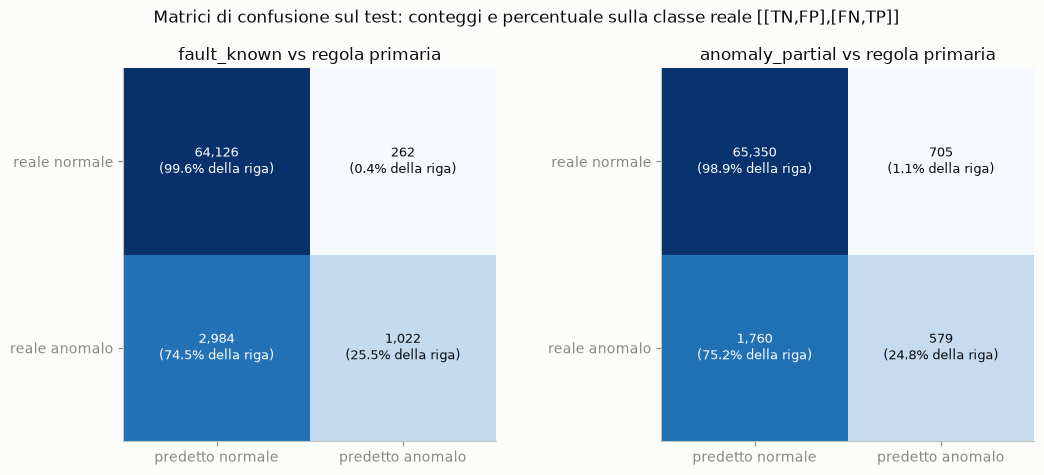

In [32]:
# --- 25. Due matrici di confusione distinte (regola primaria), una per target ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))

for ax, (target_name, m) in zip(axes, [("fault_known", metrics_fault_primary), ("anomaly_partial", metrics_partial_primary)]):
    matrix = np.array([[m["tn"], m["fp"]], [m["fn"], m["tp"]]])
    row_sums = matrix.sum(axis=1, keepdims=True)
    matrix_pct = matrix / row_sums * 100
    ax.imshow(matrix_pct, cmap="Blues", vmin=0, vmax=100)
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, f"{matrix[i, j]:,}\n({matrix_pct[i, j]:.1f}% della riga)",
                ha="center", va="center", fontsize=9,
                color="white" if matrix_pct[i, j] > 50 else COLOR_INK,
            )
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["predetto normale", "predetto anomalo"])
    ax.set_yticklabels(["reale normale", "reale anomalo"])
    ax.set_title(f"{target_name} vs regola primaria")

fig.suptitle("Matrici di confusione sul test: conteggi e percentuale sulla classe reale [[TN,FP],[FN,TP]]")
fig.tight_layout()
plt.show()

Le tabelle seguenti scompongono le stesse metriche per cluster, regime, asset e giorno UTC. I gruppi con meno di 20 positivi reali o predetti sono marcati come stime fragili: numerosità troppo piccola per ordinare i gruppi tra loro, mostrati comunque per completezza.

In [33]:
# --- 26. Metriche per sottogruppo (cluster, regime, asset, giorno UTC), regola primaria ---
GROUP_COLS = ["cluster", "regime", "asset_id", "day"]
TABLE_COLS = ["n", "positives_real", "positives_pred", "precision", "recall", "f1", "alert_rate", "fragile"]

subgroup_tables = {
    (target_col, group_col): metrics_by_group(df_test_feat, group_col, target_col, "is_anomaly_primary")
    for target_col in ["fault_known", "anomaly_partial"]
    for group_col in GROUP_COLS
}

for target_col in ["fault_known", "anomaly_partial"]:
    for group_col in GROUP_COLS:
        print(f"--- {target_col} per {group_col} ---")
        display(subgroup_tables[(target_col, group_col)][TABLE_COLS].round(4))

--- fault_known per cluster ---

,n,positives_real,positives_pred,precision,recall,f1,alert_rate,fragile
cluster,,,,,,,,
0,20270,1467,384,0.8724,0.2284,0.3620,0.0189,False
1,26703,950,417,0.5851,0.2568,0.3570,0.0156,False
2,21421,1589,483,0.9172,0.2788,0.4276,0.0225,False


--- fault_known per regime ---


,n,positives_real,positives_pred,precision,recall,f1,alert_rate,fragile
regime,,,,,,,,
0,39348,2112,563,0.8952,0.2386,0.3768,0.0143,False
1,6261,318,114,0.8684,0.3113,0.4583,0.0182,False
2,22785,1576,607,0.6903,0.2659,0.3839,0.0266,False


--- fault_known per asset_id ---


...

,n,positives_real,positives_pred,precision,recall,f1,alert_rate,fragile
regime,,,,,,,,
0,39348,1219,563,0.4813,0.2223,0.3042,0.0143,False
1,6261,185,114,0.5263,0.3243,0.4013,0.0182,False
2,22785,935,607,0.4086,0.2652,0.3217,0.0266,False


--- anomaly_partial per asset_id ---


,n,positives_real,positives_pred,precision,recall,f1,alert_rate,fragile
asset_id,,,,,,,,
0,4306,10,5,0.0000,0.0000,0.0000,0.0012,True
1,4306,288,7,0.0000,0.0000,0.0000,0.0016,True
2,4306,89,10,0.0000,0.0000,0.0000,0.0023,True
3,4181,45,17,0.3529,0.1333,0.1935,0.0041,True
4,4171,124,137,0.4891,0.5403,0.5134,0.0328,False
5,4306,117,10,0.0000,0.0000,0.0000,0.0023,True
6,4306,159,15,0.0000,0.0000,0.0000,0.0035,True
7,4306,164,248,0.5323,0.8049,0.6408,0.0576,False
8,4306,151,277,0.4946,0.9073,0.6402,0.0643,False


--- anomaly_partial per day ---


,n,positives_real,positives_pred,precision,recall,f1,alert_rate,fragile
day,,,,,,,,
2025-02-08,22562,1316,487,0.4784,0.1771,0.2585,0.0216,False
2025-02-09,22946,485,455,0.4505,0.4227,0.4362,0.0198,False
2025-02-10,22886,538,342,0.4123,0.2621,0.3205,0.0149,False


Il tasso di rilevamento seguente è calcolato soltanto sulle righe con un guasto realmente presente (`fault_code_true != 0`), suddivise per tipo. Non è precision/recall completi (non esiste una classe negativa dentro ciascun gruppo), solo la quota di righe di quel tipo di guasto effettivamente segnalata dalla regola primaria.

In [34]:
# --- 27. Tasso di rilevamento per tipo di guasto (solo righe con fault_code_true != 0) ---
fault_rows = df_test_feat[df_test_feat["fault_known"] == 1]
recall_table = recall_by_fault_type(fault_rows, "fault_type_true", "is_anomaly_primary", min_count=20)
recall_table_display = recall_table.round(4)
recall_table_display["recall_ci95"] = recall_table["recall_ci95"].apply(
    lambda ci: f"({ci[0]:.4f}, {ci[1]:.4f})" if ci is not None else "n/d"
)
display(recall_table_display)

,n,n_detected,recall,recall_ci95,fragile
fault_type_true,,,,,
bearing_wear,1193,958,0.8030,"(0.7795, 0.8246)",False
imbalance,1661,35,0.0211,"(0.0152, 0.0292)",False
overheating,1112,1,0.0009,"(0.0002, 0.0051)",False
shock,40,28,0.7000,"(0.5457, 0.8193)",False


I casi seguenti sono selezionati in modo deterministico: ordinati per rapporto distanza/soglia decrescente e poi per `(asset_id, timestamp)`, fino a 10 per categoria, non una scelta a mano degli esempi più comodi. Per `anomaly_partial`, un "falso positivo" significa soltanto "non annotato dalla label parziale", non prova di un allarme sbagliato.

In [35]:
# --- 28. Casi concreti di falso positivo e falso negativo, selezione deterministica ---
CASE_COLS = [
    "asset_id", "timestamp", "cluster", "regime", "fault_code_true", "fault_type_true",
    "anomaly_label", "dist_centroid", "threshold_primary", "dist_over_threshold_primary",
]

fp_fault = select_confusion_cases(
    df_test_feat, "fault_known", "is_anomaly_primary", "dist_over_threshold_primary",
    ["asset_id", "timestamp"], "fp", n=10,
)
fn_fault = select_confusion_cases(
    df_test_feat, "fault_known", "is_anomaly_primary", "dist_over_threshold_primary",
    ["asset_id", "timestamp"], "fn", n=10,
)
fp_partial = select_confusion_cases(
    df_test_feat, "anomaly_partial", "is_anomaly_primary", "dist_over_threshold_primary",
    ["asset_id", "timestamp"], "fp", n=10,
)
fn_partial = select_confusion_cases(
    df_test_feat, "anomaly_partial", "is_anomaly_primary", "dist_over_threshold_primary",
    ["asset_id", "timestamp"], "fn", n=10,
)

print(f"falsi positivi vs fault_known: {len(fp_fault)} mostrati")
display(fp_fault[CASE_COLS])
print(f"\nfalsi negativi vs fault_known: {len(fn_fault)} mostrati")
display(fn_fault[CASE_COLS])
print(f"\nfalsi positivi vs anomaly_partial: {len(fp_partial)} mostrati")
display(fp_partial[CASE_COLS])
print(f"\nfalsi negativi vs anomaly_partial: {len(fn_partial)} mostrati")
display(fn_partial[CASE_COLS])

falsi positivi vs fault_known: 10 mostrati


,asset_id,timestamp,cluster,regime,fault_code_true,fault_type_true,anomaly_label,dist_centroid,threshold_primary,dist_over_threshold_primary
46143,10,2025-02-10 09:31:00+00:00,0,0,0,normal,0,24.741430,12.829047,1.928548
56470,13,2025-02-08 15:36:00+00:00,0,1,0,normal,0,24.005076,12.829047,1.871150
19886,4,2025-02-09 23:34:00+00:00,1,1,0,normal,0,10.857250,5.869004,1.849931
56426,13,2025-02-08 14:52:00+00:00,0,0,0,normal,0,23.170168,12.829047,1.806071
56451,13,2025-02-08 15:17:00+00:00,0,0,0,normal,0,23.026123,12.829047,1.794843
19892,4,2025-02-09 23:40:00+00:00,1,0,0,normal,0,10.462504,5.869004,1.782671
19896,4,2025-02-09 23:44:00+00:00,1,0,0,normal,0,10.450490,5.869004,1.780624
19894,4,2025-02-09 23:42:00+00:00,1,0,0,normal,0,10.429485,5.869004,1.777045
19890,4,2025-02-09 23:38:00+00:00,1,0,0,normal,0,10.402864,5.869004,1.772509
19887,4,2025-02-09 23:35:00+00:00,1,0,0,normal,0,10.391181,5.869004,1.770519



falsi negativi vs fault_known: 10 mostrati


,asset_id,timestamp,cluster,regime,fault_code_true,fault_type_true,anomaly_label,dist_centroid,threshold_primary,dist_over_threshold_primary
43837,10,2025-02-08 19:05:00+00:00,1,1,3,imbalance,1,5.866873,5.869004,0.999637
41599,9,2025-02-10 05:33:00+00:00,0,2,1,bearing_wear,1,12.817753,12.829047,0.999120
52440,12,2025-02-08 19:37:00+00:00,2,2,1,bearing_wear,1,11.192014,11.204549,0.998881
41682,9,2025-02-10 06:56:00+00:00,0,0,1,bearing_wear,0,12.793583,12.829047,0.997236
41550,9,2025-02-10 04:44:00+00:00,0,0,1,bearing_wear,0,12.773929,12.829047,0.995704
13162,3,2025-02-08 04:19:00+00:00,1,1,3,imbalance,1,5.842001,5.869004,0.995399
52489,12,2025-02-08 20:26:00+00:00,0,0,1,bearing_wear,0,12.767264,12.829047,0.995184
64470,15,2025-02-08 05:24:00+00:00,1,0,3,imbalance,0,5.836099,5.869004,0.994394
41551,9,2025-02-10 04:45:00+00:00,0,0,1,bearing_wear,1,12.754095,12.829047,0.994158
52445,12,2025-02-08 19:42:00+00:00,2,2,1,bearing_wear,1,11.134340,11.204549,0.993734



falsi positivi vs anomaly_partial: 10 mostrati


,asset_id,timestamp,cluster,regime,fault_code_true,fault_type_true,anomaly_label,dist_centroid,threshold_primary,dist_over_threshold_primary
41471,9,2025-02-10 03:25:00+00:00,1,0,1,bearing_wear,0,12.968978,5.869004,2.209741
18796,4,2025-02-09 05:24:00+00:00,1,1,1,bearing_wear,0,12.608335,5.869004,2.148292
18760,4,2025-02-09 04:48:00+00:00,1,1,1,bearing_wear,0,12.595837,5.869004,2.146163
56450,13,2025-02-08 15:16:00+00:00,2,2,4,shock,0,24.019430,11.204549,2.143721
41664,9,2025-02-10 06:38:00+00:00,1,1,1,bearing_wear,0,12.533970,5.869004,2.135621
41673,9,2025-02-10 06:47:00+00:00,1,0,1,bearing_wear,0,12.361605,5.869004,2.106253
18690,4,2025-02-09 03:38:00+00:00,1,1,1,bearing_wear,0,11.760664,5.869004,2.003860
41518,9,2025-02-10 04:12:00+00:00,1,1,1,bearing_wear,0,11.693012,5.869004,1.992333
41662,9,2025-02-10 06:36:00+00:00,1,1,1,bearing_wear,0,11.552956,5.869004,1.968470
31145,7,2025-02-08 21:17:00+00:00,1,2,1,bearing_wear,0,11.500652,5.869004,1.959558



falsi negativi vs anomaly_partial: 10 mostrati


,asset_id,timestamp,cluster,regime,fault_code_true,fault_type_true,anomaly_label,dist_centroid,threshold_primary,dist_over_threshold_primary
43837,10,2025-02-08 19:05:00+00:00,1,1,3,imbalance,1,5.866873,5.869004,0.999637
41599,9,2025-02-10 05:33:00+00:00,0,2,1,bearing_wear,1,12.817753,12.829047,0.999120
52440,12,2025-02-08 19:37:00+00:00,2,2,1,bearing_wear,1,11.192014,11.204549,0.998881
13162,3,2025-02-08 04:19:00+00:00,1,1,3,imbalance,1,5.842001,5.869004,0.995399
41551,9,2025-02-10 04:45:00+00:00,0,0,1,bearing_wear,1,12.754095,12.829047,0.994158
52445,12,2025-02-08 19:42:00+00:00,2,2,1,bearing_wear,1,11.134340,11.204549,0.993734
60240,14,2025-02-08 06:40:00+00:00,1,1,3,imbalance,1,5.801168,5.869004,0.988442
41519,9,2025-02-10 04:13:00+00:00,0,0,1,bearing_wear,1,12.677787,12.829047,0.988210
41629,9,2025-02-10 06:03:00+00:00,2,1,1,bearing_wear,1,11.046090,11.204549,0.985858
41612,9,2025-02-10 05:46:00+00:00,0,0,1,bearing_wear,1,12.628571,12.829047,0.984373


La coerenza temporale guarda oltre il confronto riga per riga: segmenta le finestre contigue di guasto reale per asset e verifica se e quando la regola primaria le intercetta, senza mai attraversare il confine tra due asset diversi.

In [36]:
# --- 29. Coerenza temporale: eventi di guasto contigui, copertura, ritardo, prossimita degli alert ---
events = segment_fault_events(df_test_feat, "asset_id", "timestamp", "fault_code_true")
coverage = event_alert_coverage(events, df_test_feat, "asset_id", "timestamp", "is_anomaly_primary")


def _event_fault_type(row):
    window = df_test_feat[
        (df_test_feat["asset_id"] == row["asset_id"])
        & (df_test_feat["timestamp"] >= row["start"])
        & (df_test_feat["timestamp"] <= row["end"])
    ]
    return window["fault_type_true"].mode().iloc[0]


coverage["fault_type"] = coverage.apply(_event_fault_type, axis=1)

print(f"eventi di guasto contigui nel test: {len(events)}")
print(f"eventi troncati a inizio o fine asset: {int((events['truncated_start'] | events['truncated_end']).sum())}")
print(
    f"eventi con almeno un alert della regola primaria: {int(coverage['has_alert'].sum())} / {len(coverage)} "
    f"({coverage['has_alert'].mean() * 100:.2f}%)"
)
print(
    "ritardo del primo alert dall'inizio dell'evento, minuti (solo eventi con alert): "
    f"media={coverage.loc[coverage['has_alert'], 'delay_minutes'].mean():.2f}  "
    f"mediana={coverage.loc[coverage['has_alert'], 'delay_minutes'].median():.2f}"
)
print(f"copertura media (frazione di minuti dell'evento con alert attivo): {coverage['coverage'].mean() * 100:.2f}%")

print("\nscomposizione per tipo di guasto dominante nell'evento:")
display(
    coverage.groupby("fault_type").agg(
        n_eventi=("fault_type", "size"),
        durata_media_min=("n_rows", "mean"),
        quota_con_alert=("has_alert", "mean"),
        copertura_media=("coverage", "mean"),
    ).round(4)
)

near = alerts_near_fault_windows(df_test_feat, "asset_id", "timestamp", "is_anomaly_primary", events, window_minutes=15)
print(
    f"\nalert entro +-15 minuti da una finestra di guasto noto (stesso asset): "
    f"{near['n_near']:,} / {near['n_alerts']:,} ({near['fraction_near'] * 100:.2f}%)"
)

eventi di guasto contigui nel test: 55
eventi troncati a inizio o fine asset: 0


eventi con almeno un alert della regola primaria: 36 / 55 (65.45%)
ritardo del primo alert dall'inizio dell'evento, minuti (solo eventi con alert): media=8.97  mediana=0.00
copertura media (frazione di minuti dell'evento con alert attivo): 54.26%

scomposizione per tipo di guasto dominante nell'evento:


,n_eventi,durata_media_min,quota_con_alert,copertura_media
fault_type,,,,
bearing_wear,6,198.8333,1.0000,0.7681
imbalance,8,207.6250,0.5000,0.0285
overheating,5,222.4000,0.2000,0.0017
shock,36,1.1111,0.6944,0.6944



alert entro +-15 minuti da una finestra di guasto noto (stesso asset): 1,126 / 1,284 (87.69%)

Il grafico seguente mostra, per ciascuno dei 16 asset, il rapporto tra la distanza dal centroide e la soglia della regola primaria in vigore in quel momento (il denominatore cambia riga per riga in base al cluster assegnato): un valore sopra 1 indica un alert. Le finestre con guasto noto e gli alert prodotti sono evidenziati, senza campionare nessuna riga.

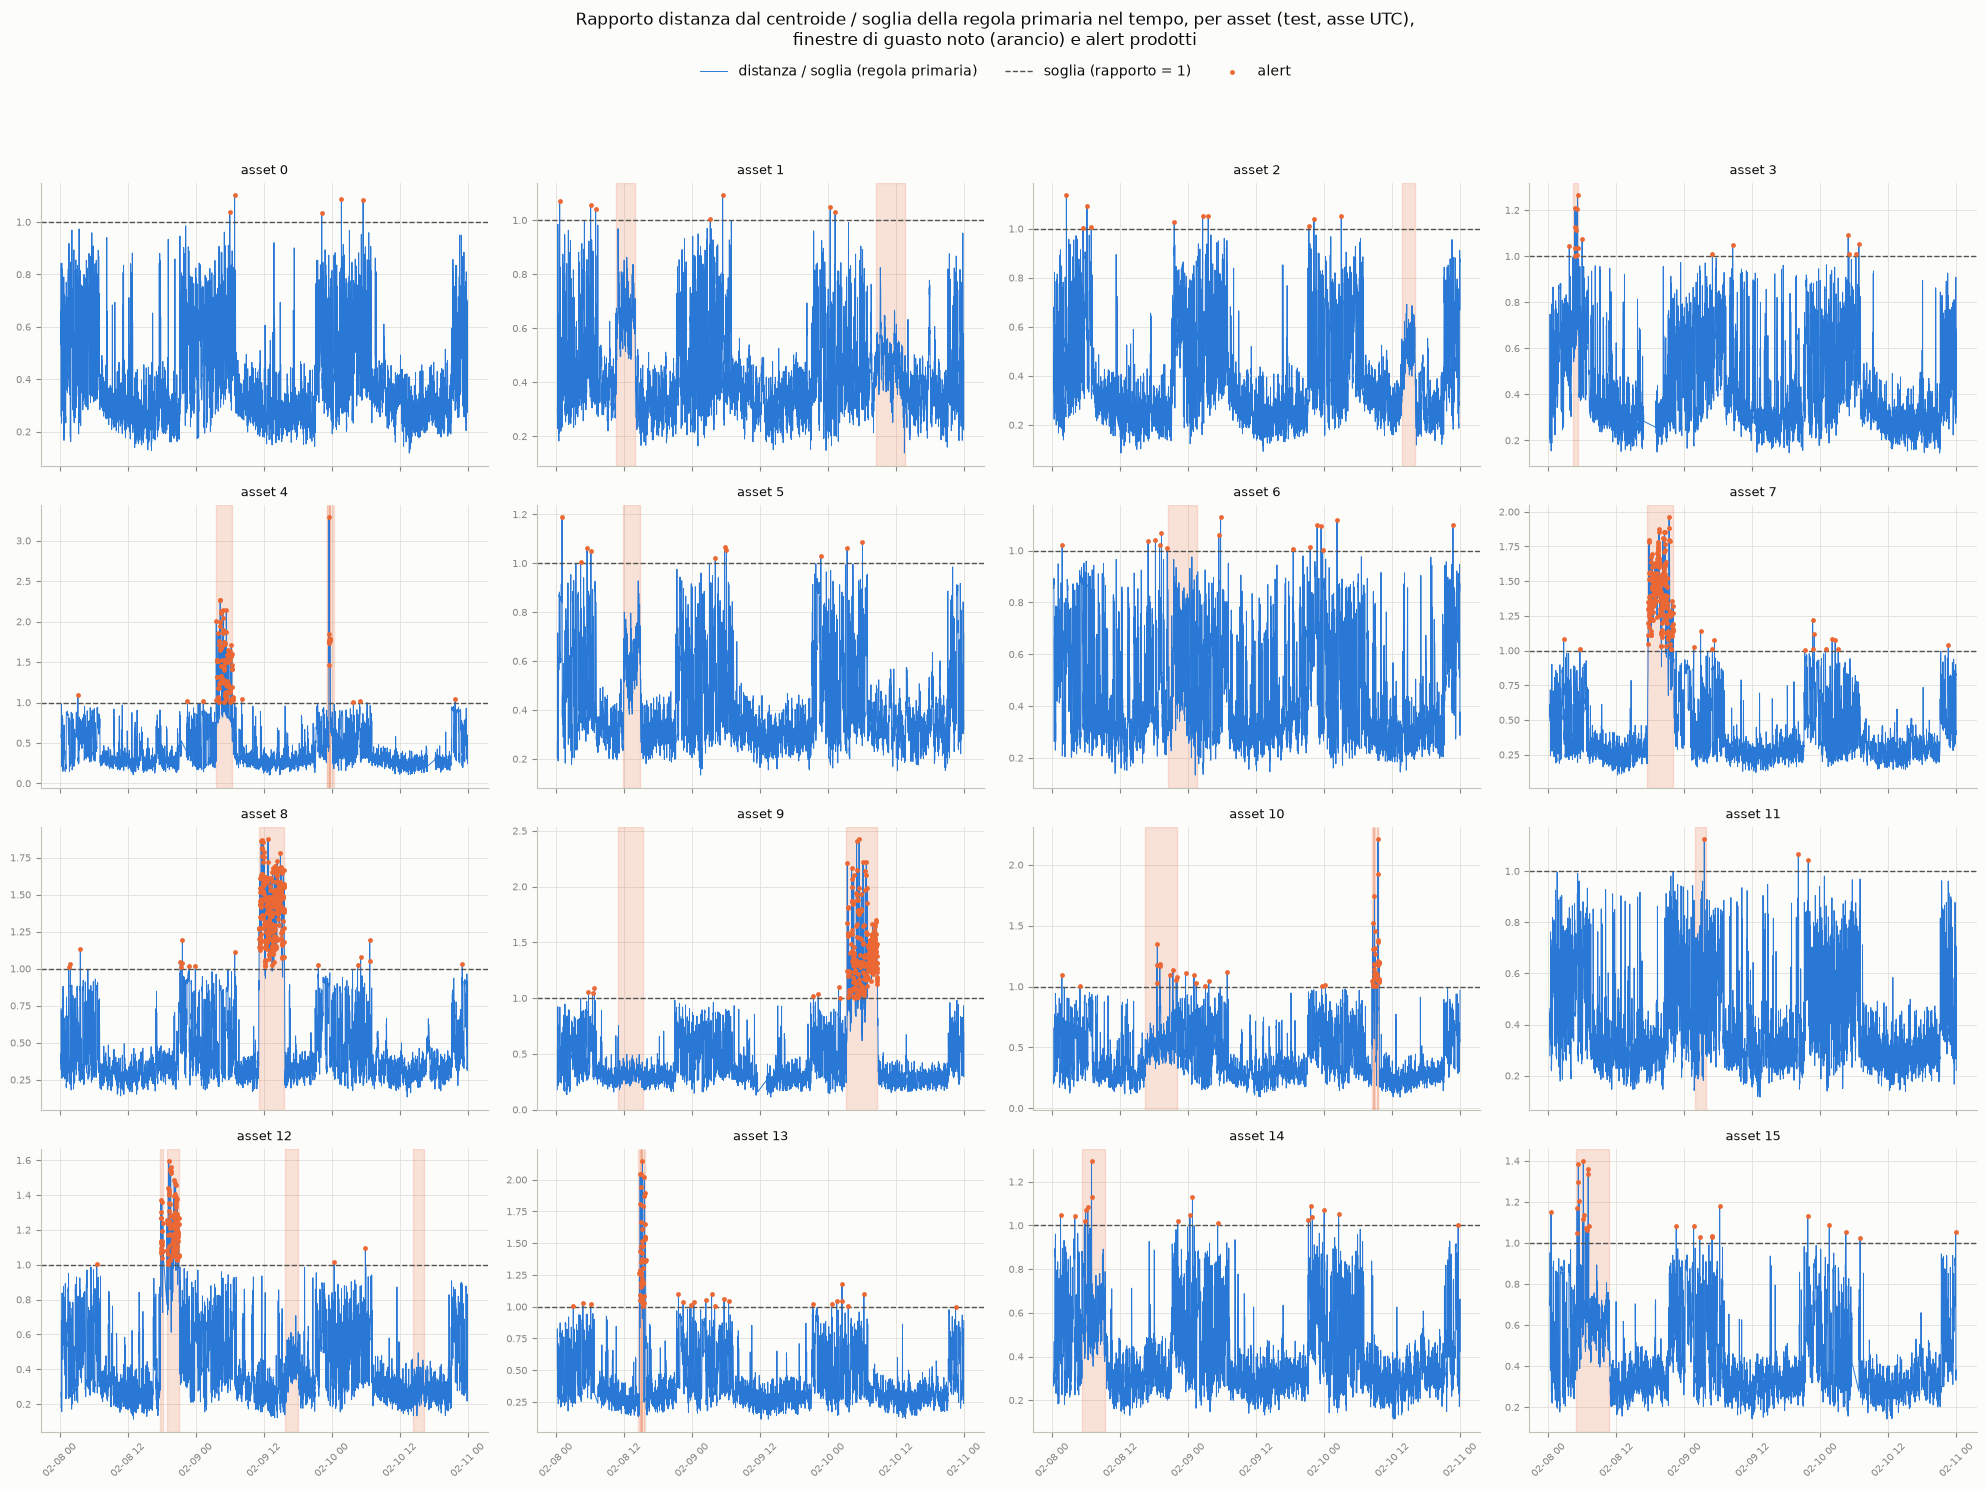

In [37]:
# --- 30. Linea temporale del test per tutti i 16 asset: rapporto distanza/soglia, guasti, alert ---
assets_sorted = sorted(df_test_feat["asset_id"].unique())
fig, axes = plt.subplots(4, 4, figsize=(20, 14), sharex=True)
axes = axes.ravel()

for ax, asset in zip(axes, assets_sorted):
    part = df_test_feat[df_test_feat["asset_id"] == asset].sort_values("timestamp")
    ax.plot(
        part["timestamp"], part["dist_over_threshold_primary"], color=COLOR_BLUE, linewidth=0.7,
        zorder=2, label="distanza / soglia (regola primaria)",
    )
    ax.axhline(1.0, color=COLOR_INK_SECONDARY, linewidth=1.0, linestyle="--", zorder=2, label="soglia (rapporto = 1)")

    for _, ev in events[events["asset_id"] == asset].iterrows():
        ax.axvspan(ev["start"], ev["end"], color=COLOR_ORANGE, alpha=0.18, zorder=1)

    alerted = part[part["is_anomaly_primary"]]
    ax.scatter(alerted["timestamp"], alerted["dist_over_threshold_primary"], color=COLOR_ORANGE, s=6, zorder=3, label="alert")

    ax.set_title(f"asset {asset}", fontsize=9)
    ax.set_axisbelow(True)
    ax.grid(color=COLOR_GRID, linewidth=0.6)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.03))
fig.suptitle(
    "Rapporto distanza dal centroide / soglia della regola primaria nel tempo, per asset (test, asse UTC),\n"
    "finestre di guasto noto (arancio) e alert prodotti",
    y=1.06,
)
fig.tight_layout()
plt.show()

In [38]:
# --- 31. Riconciliazione finale: nessun artefatto della Fase 4 modificato, sentinella anti-tuning ---
assert np.array_equal(scaler.mean_, _scaler_mean_snapshot)
assert np.array_equal(pca.components_, _pca_components_snapshot)
assert np.array_equal(kmeans.cluster_centers_, _kmeans_centers_snapshot)
assert thresholds_p99["per_cluster_threshold"] == _thresholds_snapshot
assert thresholds_p99["global_threshold"] == _global_threshold_snapshot
print("OK: scaler, PCA, K-Means e soglie della Fase 4 restano invariati dopo tutta la Fase 5.")

_flags_before = df_test_feat["is_anomaly_primary"].to_numpy().copy()
_dist_before = df_test_feat["dist_centroid"].to_numpy().copy()
_rng_sentinel = np.random.default_rng(SEED)
for _ in range(3):
    permuted_labels = _rng_sentinel.integers(0, 2, size=len(df_test_feat))
    classification_metrics(permuted_labels, df_test_feat["is_anomaly_primary"].astype(int).to_numpy())
assert np.array_equal(df_test_feat["is_anomaly_primary"].to_numpy(), _flags_before)
assert np.array_equal(df_test_feat["dist_centroid"].to_numpy(), _dist_before)
print("OK: permutare le label non modifica distanze o flag di anomalia gia' calcolati (sentinella anti-tuning).")

g_check = metrics_by_group(df_test_feat, "cluster", "fault_known", "is_anomaly_primary")
global_check = confusion_counts(df_test_feat["fault_known"], df_test_feat["is_anomaly_primary"])
assert g_check[["tn", "fp", "fn", "tp"]].sum().to_dict() == global_check
print("OK: la somma delle matrici di confusione per cluster coincide con la matrice globale.")

OK: scaler, PCA, K-Means e soglie della Fase 4 restano invariati dopo tutta la Fase 5.
OK: permutare le label non modifica distanze o flag di anomalia gia' calcolati (sentinella anti-tuning).
OK: la somma delle matrici di confusione per cluster coincide con la matrice globale.


In [39]:
# --- 32. Tempo e memoria della validazione sul test reale, nessun campionamento ---
import tracemalloc


def _run_validation_block():
    _ = merge_predictions_and_labels(
        df_test_feat[["asset_id", "timestamp", "is_anomaly_primary"]],
        df_test_feat[["asset_id", "timestamp", "fault_known", "anomaly_partial"]],
    )
    _ = classification_metrics_with_intervals(df_test_feat["fault_known"], df_test_feat["is_anomaly_primary"])
    _ = classification_metrics_with_intervals(df_test_feat["anomaly_partial"], df_test_feat["is_anomaly_primary"])


t0 = time.perf_counter()
_run_validation_block()
elapsed = time.perf_counter() - t0

tracemalloc.start()
_run_validation_block()
_, peak_memory = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f"tempo per allineamento per chiave + metriche complete su {len(df_test_feat):,} righe reali di test: {elapsed * 1000:.1f} ms")
print(f"picco di memoria allocata durante lo stesso blocco (tracemalloc, misurato separatamente dal tempo perche' il profiling di tracemalloc rallenta l'esecuzione): {peak_memory / 1024:.1f} KB")
print("nessun campionamento: l'intero test viene validato riga per riga.")

tempo per allineamento per chiave + metriche complete su 68,394 righe reali di test: 208.5 ms
picco di memoria allocata durante lo stesso blocco (tracemalloc, misurato separatamente dal tempo perche' il profiling di tracemalloc rallenta l'esecuzione): 28588.8 KB
nessun campionamento: l'intero test viene validato riga per riga.


### Risultati chiave e giudizio critico (Fase 5)

**1. Il risultato più netto, e il più scomodo.** Sul test, la regola primaria (P99 per cluster) ottiene F1=0,3864 contro `fault_known` (precision 0,7960, recall 0,2551) e F1=0,3196 contro `anomaly_partial` (precision 0,4509, recall 0,2475). Il benchmark (P99 globale) fa **meglio su entrambi i fronti**: F1=0,4608 contro `fault_known` (precision 0,8869, recall 0,3113) e F1=0,3728 contro `anomaly_partial` (precision 0,4964, recall 0,2984), pur segnalando un volume di alert leggermente superiore (2,056% contro 1,877%). La regola scelta in Fase 4 per riequilibrare l'alert rate tra i tre cluster non è quindi la scelta migliore in termini di rilevamento dei guasti: un compromesso esplicito, non un risultato nascosto.

**2. Il costo si concentra esattamente dove Fase 4 lo aveva previsto.** Scomponendo il recall di `fault_known` per cluster, il benchmark supera nettamente la regola primaria proprio nei cluster 0 e 2 (38,51% contro 22,84% nel cluster 0, 34,80% contro 27,88% nel cluster 2), mentre la regola primaria resta preferibile solo nel cluster 1 (25,68% contro 13,58%). Fase 4 aveva già mostrato che le soglie ufficiali dei cluster 0 e 2 sono gonfiate dalla contaminazione del train (guasti noti non filtrati): ricalibrate su un train "known-clean" scendevano rispettivamente del 50,02% e del 42,60%, contro appena il 2,22% nel cluster 1. La Fase 5 conferma l'effetto pratico previsto: soglie più alte in quei due cluster lasciano passare inosservati più guasti reali, ed è lì che si concentrano la maggior parte dei guasti del test (1.467 e 1.589 casi, contro 950 nel cluster 1).

**3. Le due label raccontano storie diverse, non la stessa storia vista da due angoli.** Sul test, 1.803 righe hanno `fault_code_true != 0` ma `anomaly_label == 0`, e 136 righe hanno `anomaly_label == 1` senza un codice di guasto noto; solo 2.203 righe coincidono su entrambe. `anomaly_partial` produce sistematicamente F1 più basso della validazione contro `fault_known`, coerente con la sua natura di annotazione parziale dichiarata fin dall'inizio, un motivo in più per non trattarla come riferimento definitivo.

**4. Il limite più concreto: due tipi di guasto quasi invisibili al modello.** Il tasso di rilevamento per tipo di guasto (solo righe con `fault_code_true != 0`) è molto disomogeneo: `bearing_wear` all'80,30% (958/1.193) e `shock` al 70,00% (28/40) sono rilevati bene, ma `imbalance` crolla al 2,11% (35/1.661) e `overheating` è quasi invisibile allo 0,09% (1/1.112). La segmentazione per eventi conferma lo stesso quadro con un'altra lente: i 6 eventi di `bearing_wear` (durata media 198,8 minuti) hanno copertura media del 76,81% dei minuti con alert attivo, mentre gli 8 eventi di `imbalance` e i 5 di `overheating` (durata media comparabile, oltre 200 minuti) hanno copertura media rispettivamente del 2,85% e dello 0,17%. Non è un problema di eventi troppo brevi per essere notati: la distanza dal centroide durante quei guasti semplicemente non si allontana abbastanza dalla soglia.

**5. Gli alert non sono sparsi a caso nel tempo, anche dove il recall riga-per-riga è modesto.** Su 55 eventi di guasto contiguo nel test (nessuno troncato ai bordi dell'osservazione), il 65,45% (36/55) riceve almeno un alert della regola primaria; il ritardo del primo alert è mediano a 0 minuti ma con una media di 8,97 minuti, trainata da una coda di eventi rilevati con ritardo (fino a un massimo di 124 minuti), un quadro bimodale coerente con il fatto che 32 dei 55 eventi durano un solo minuto (verosimilmente gli spike di `shock`) mentre gli altri si estendono per ore. A livello di singola riga, l'87,69% degli alert prodotti (1.126 su 1.284) cade entro ±15 minuti da una finestra di guasto noto dello stesso asset, un margine di coerenza temporale che il solo F1 riga-per-riga non racconta.

**6. Numerosità fragile in alcuni sottogruppi, da non usare per graduare gli asset.** L'asset 0 non ha guasti noti nel test ma riceve comunque 5 alert (tutti falsi positivi rispetto a `fault_known`, recall non definito per assenza di positivi reali); l'asset 13 ha solo 15 guasti noti (sotto la soglia di affidabilità di 20) a fronte di 73 alert, con precision 0,1781 e recall 0,8667: numeri che con un campione così piccolo vanno letti come indicativi, non come giudizio definitivo sull'asset.

**7. Costo operativo, senza soglia di accettabilità dichiarata.** La regola primaria produce 1.284 alert sulle 68.394 righe di test, in 3 giorni su 16 asset: circa 428 alert al giorno in totale, cioè 1.284 / 3 / 16 = 26,75, poco meno di 27 per asset al giorno. Se questo volume sia sostenibile per chi dovrebbe rivederli è una decisione operativa che non spetta a questa fase e che richiede un contesto (capacità del team di manutenzione, costo di un falso allarme) non disponibile qui.

**8. Cosa resta della regola scelta in Fase 4.** Il confronto non fa fallire la regola primaria per costruzione: resta la scelta più equa tra i tre cluster, un criterio dichiarato prima di guardare questi risultati e che continua a valere come tale. Ma la Fase 5 rende esplicito il prezzo pagato in termini di rilevamento assoluto, concentrato nei due cluster più colpiti dalla contaminazione del train, un punto da portare avanti a un'eventuale iterazione futura del modello (train più pulito, soglia diversa, o accettazione consapevole del compromesso), non da nascondere dietro un unico numero di F1.

## 8. Fase 6: Reporting e visualizzazione

Le fasi precedenti hanno prodotto numeri e tabelle. Questa fase serve a renderli leggibili: non
aggiunge modelli, non cambia parametri e non rimette in discussione nessuna decisione già presa.
Scaler, PCA, K-Means, centroidi, soglie e classificazione restano esattamente quelli calibrati
prima; qui vengono soltanto consumati per costruire le viste finali. A fine sezione un controllo
esplicito verifica che nessuno di questi oggetti sia stato toccato.

Cosa aggiunge questa sezione, e cosa invece è già stato mostrato:

- **già presente, non duplicato**: l'andamento temporale del rapporto tra distanza e soglia per
  ciascuno dei 16 asset, con le finestre di guasto noto e gli alert, è il grafico della sezione
  precedente. È la risposta diretta alla domanda "quando il sistema si allontana dal normale" e
  non viene rifatto in altra forma;
- **nuovo**: la proiezione dei cluster con gli alert del test evidenziati sopra, la concentrazione
  degli alert nel tempo per regime operativo, il confronto tra le distribuzioni delle distanze dei
  punti normali e di quelli segnalati, la matrice di dispersione dei principali segnali di macchina
  colorata per cluster, e la sintesi conclusiva.

Un'avvertenza che vale per tutti i grafici che seguono. Dove il numero di punti renderebbe la
figura illeggibile viene disegnato un campione, mai un calcolo su campione: conteggi, tassi e
metriche restano quelli dell'insieme completo, e ogni campionamento dichiara accanto al grafico
la propria numerosità, la frazione e il fatto di essere riproducibile. Gli alert non vengono mai
campionati: un grafico che dice di mostrarli li mostra tutti.

In [40]:
# --- 33. Fase 6: fotografia degli artefatti approvati, da riverificare a fine sezione ---
from matplotlib.colors import LinearSegmentedColormap

from src.reporting import (
    PAIR_PLOT_SIGNALS,
    alert_heatmap_table,
    distances_by_flag,
    pair_plot_frame,
    split_background_and_alerts,
)

_phase6_scaler_mean = scaler.mean_.copy()
_phase6_pca_components = pca.components_.copy()
_phase6_kmeans_centers = kmeans.cluster_centers_.copy()
_phase6_thresholds = dict(thresholds_p99["per_cluster_threshold"])
_phase6_global_threshold = thresholds_p99["global_threshold"]
_phase6_test_distances = df_test_feat["dist_centroid"].to_numpy().copy()
_phase6_test_flags = df_test_feat["is_anomaly_primary"].to_numpy().copy()

# palette sequenziali coerenti con il resto del notebook: arancio per cio che riguarda gli alert,
# blu per le numerosita di supporto
CMAP_ALERT = LinearSegmentedColormap.from_list("alert", ["#fcfcfb", COLOR_ORANGE])
CMAP_SUPPORT = LinearSegmentedColormap.from_list("support", ["#fcfcfb", COLOR_BLUE])
CMAP_ALERT.set_bad(COLOR_GRID)
CMAP_SUPPORT.set_bad(COLOR_GRID)

print(f"righe di test da rappresentare: {len(df_test_feat):,}")
print(f"alert della regola primaria sul test: {int(df_test_feat['is_anomaly_primary'].sum()):,}")
print(f"asset: {df_test_feat['asset_id'].nunique()}   "
      f"regimi: {sorted(int(r) for r in df_test_feat['regime'].unique())}   "
      f"cluster: {sorted(int(c) for c in df_test_feat['cluster'].unique())}")

righe di test da rappresentare: 68,394
alert della regola primaria sul test: 1,284
asset: 16   regimi: [0, 1, 2]   cluster: [0, 1, 2]


Il grafico seguente riprende la proiezione sulle prime due componenti principali già usata per
descrivere i cluster, ma questa volta sui dati di test e con gli alert della regola primaria
evidenziati sopra. Serve a vedere *dove* cadono i punti segnalati rispetto alla struttura appresa:
se si disponessero in modo compatto attorno a un solo centroide, il modello starebbe soprattutto
segnalando uno stato operativo invece che una deviazione. Lo sfondo è un campione stratificato dei
punti non segnalati, gli alert sono tutti presenti.

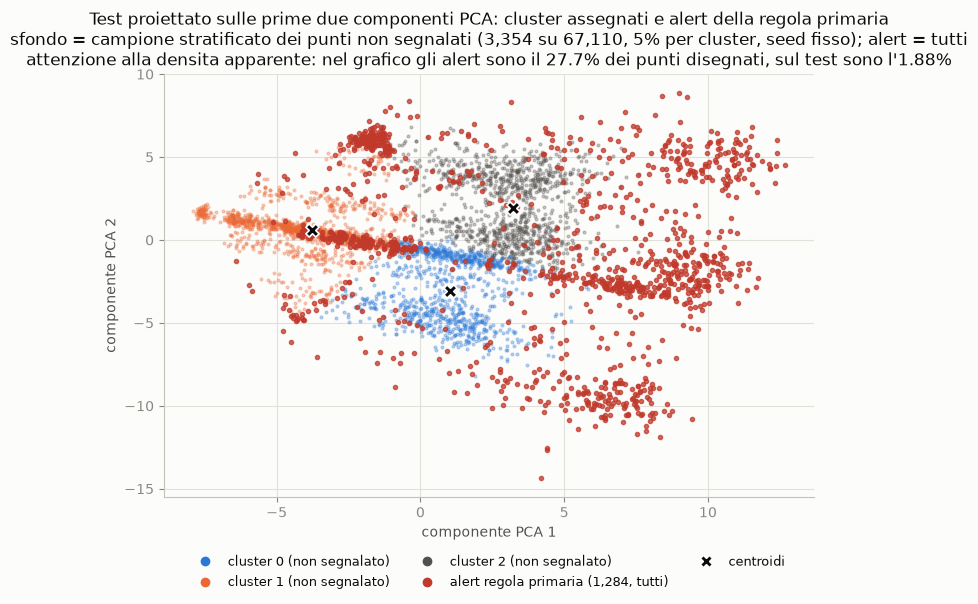

In [41]:
# --- 34. Proiezione PCA del test: cluster sullo sfondo, alert della regola primaria evidenziati ---
SCATTER_BACKGROUND_FRACTION = 0.05

scatter_test = df_test_feat[["asset_id", "timestamp", "cluster", "is_anomaly_primary"]].copy()
scatter_test["pc1"] = X_test_pca[:, 0]
scatter_test["pc2"] = X_test_pca[:, 1]

background_test, alerts_test = split_background_and_alerts(
    scatter_test, alert_col="is_anomaly_primary", group_col="cluster",
    fraction=SCATTER_BACKGROUND_FRACTION, seed=SEED,
)

fig, ax = plt.subplots(figsize=(7.5, 6.2))
cluster_colors = [COLOR_BLUE, COLOR_ORANGE, COLOR_INK_SECONDARY]
for c in sorted(background_test["cluster"].unique()):
    part = background_test[background_test["cluster"] == c]
    ax.scatter(part["pc1"], part["pc2"], s=4, alpha=0.30, color=cluster_colors[c % len(cluster_colors)],
               zorder=2, rasterized=True)

ax.scatter(alerts_test["pc1"], alerts_test["pc2"], s=9, color="#c0392b", alpha=0.75,
           zorder=4, rasterized=True)

centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], s=90, marker="X", color=COLOR_INK,
           edgecolor="white", linewidth=1.2, zorder=5)

real_alert_share = scatter_test["is_anomaly_primary"].mean() * 100
drawn_alert_share = len(alerts_test) / (len(alerts_test) + len(background_test)) * 100

ax.set_xlabel("componente PCA 1")
ax.set_ylabel("componente PCA 2")
ax.set_title(
    "Test proiettato sulle prime due componenti PCA: cluster assegnati e alert della regola primaria\n"
    f"sfondo = campione stratificato dei punti non segnalati ({len(background_test):,} su "
    f"{int((~scatter_test['is_anomaly_primary']).sum()):,}, 5% per cluster, seed fisso); alert = tutti\n"
    f"attenzione alla densita apparente: nel grafico gli alert sono il {drawn_alert_share:.1f}% dei punti "
    f"disegnati, sul test sono l'{real_alert_share:.2f}%"
)
ax.set_axisbelow(True)
ax.grid(color=COLOR_GRID, linewidth=0.8)

# Handle di legenda espliciti: la dimensione del simbolo nella legenda va scelta, non ricavata
# scalando quella usata nel grafico, altrimenti il marcatore dei centroidi finisce per invadere
# l'area del disegno.
legend_handles = [
    plt.Line2D([], [], marker="o", linestyle="", markersize=6, color=cluster_colors[c % len(cluster_colors)],
               label=f"cluster {c} (non segnalato)")
    for c in sorted(background_test["cluster"].unique())
]
legend_handles.append(plt.Line2D([], [], marker="o", linestyle="", markersize=6, color="#c0392b",
                                 label=f"alert regola primaria ({len(alerts_test):,}, tutti)"))
legend_handles.append(plt.Line2D([], [], marker="X", linestyle="", markersize=9, color=COLOR_INK,
                                 markeredgecolor="white", label="centroidi"))
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=3,
          frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

Il grafico seguente risponde a una domanda diversa: non dove cadono gli alert nello spazio delle
feature, ma quando si concentrano e in quale regime operativo. I tre pannelli vanno letti insieme e
proprio per questo sono separati: il primo mostra il **numero** di alert per ogni ora e regime, il
secondo la **quota** di righe segnalate nella stessa cella, il terzo il **supporto**, cioè quante
righe erano effettivamente disponibili in quella cella. Un pannello solo sarebbe fuorviante: molte
segnalazioni in una cella molto popolata non significano un tasso alto, e un tasso alto calcolato su
poche righe non significa granché. Le celle senza alcuna osservazione sono in grigio e non hanno un
tasso definito, che è cosa diversa da un tasso pari a zero.

celle (ora x regime): 216   di cui senza osservazioni: 0
righe ricomposte: 68,394 (test: 68,394)   alert ricomposti: 1,284


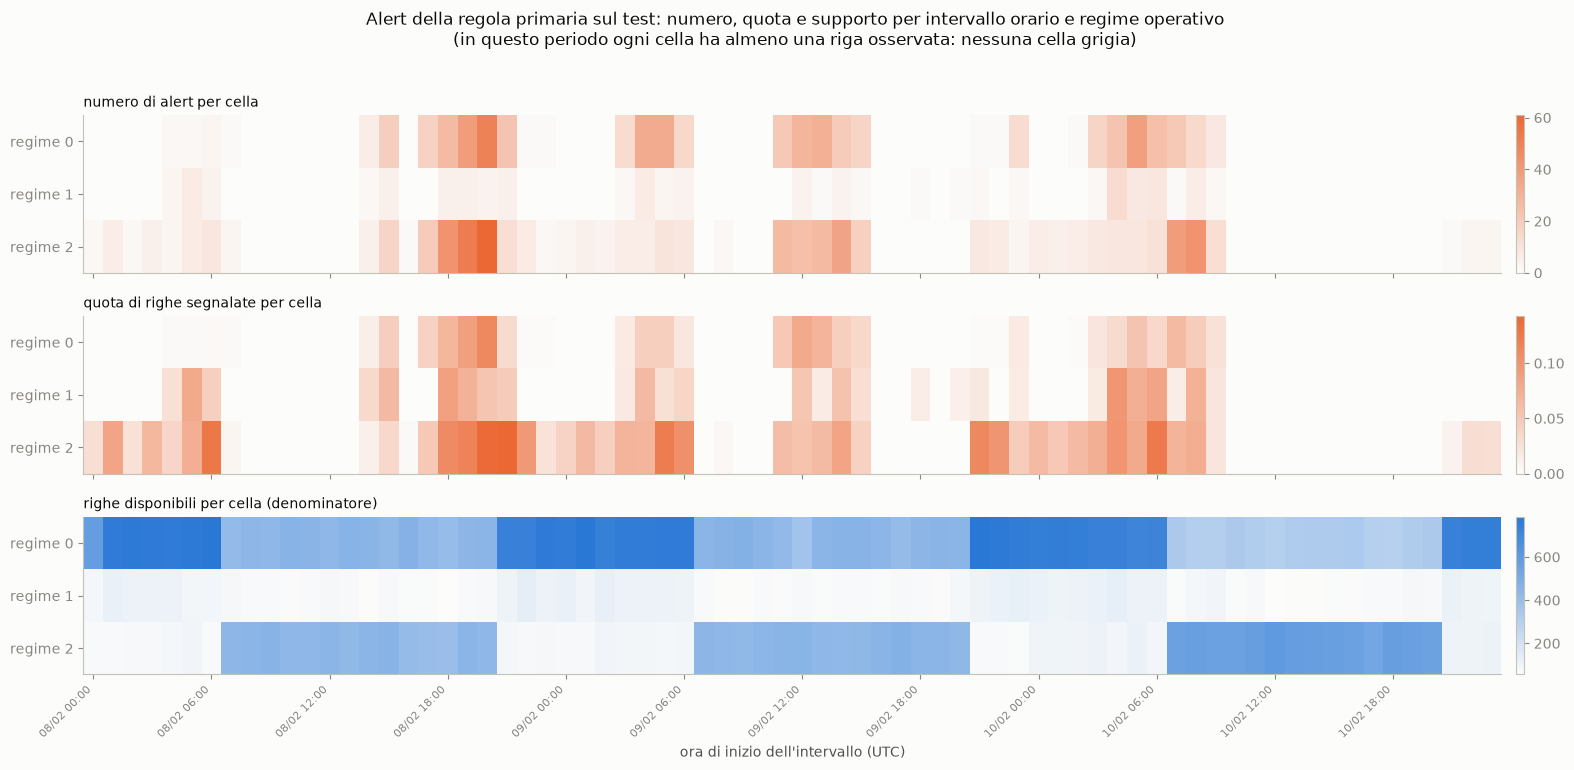

In [42]:
# --- 35. Concentrazione degli alert nel tempo per regime operativo, con i denominatori ---
HEATMAP_FREQ = "1h"

heatmap_table = alert_heatmap_table(
    df_test_feat, timestamp_col="timestamp", group_col="regime",
    alert_col="is_anomaly_primary", freq=HEATMAP_FREQ,
)

# riconciliazione: la scomposizione in celle deve conservare esattamente righe e alert totali
assert heatmap_table["support"].sum() == len(df_test_feat)
assert heatmap_table["alerts"].sum() == int(df_test_feat["is_anomaly_primary"].sum())
n_empty_cells = int((heatmap_table["support"] == 0).sum())
print(f"celle (ora x regime): {len(heatmap_table)}   di cui senza osservazioni: {n_empty_cells}")
print(f"righe ricomposte: {heatmap_table['support'].sum():,} (test: {len(df_test_feat):,})   "
      f"alert ricomposti: {heatmap_table['alerts'].sum():,}")

grids = {
    name: heatmap_table.pivot(index="regime", columns="bin_start", values=name)
    for name in ("alerts", "alert_rate", "support")
}
bins = grids["alerts"].columns
regimes = grids["alerts"].index

panels = [
    ("alerts", "numero di alert per cella", CMAP_ALERT, None),
    ("alert_rate", "quota di righe segnalate per cella", CMAP_ALERT, None),
    ("support", "righe disponibili per cella (denominatore)", CMAP_SUPPORT, None),
]

fig, axes = plt.subplots(3, 1, figsize=(16, 7.5), sharex=True)
tick_positions = range(0, len(bins), 6)
for ax, (name, subtitle, cmap, _) in zip(axes, panels):
    values = grids[name].to_numpy(dtype=float)
    im = ax.imshow(values, aspect="auto", cmap=cmap, interpolation="nearest")
    ax.set_yticks(range(len(regimes)))
    ax.set_yticklabels([f"regime {r}" for r in regimes])
    ax.set_title(subtitle, fontsize=10, loc="left")
    ax.set_xticks(list(tick_positions))
    ax.grid(False)
    fig.colorbar(im, ax=ax, pad=0.01, fraction=0.025)

axes[-1].set_xticklabels([bins[i].strftime("%d/%m %H:%M") for i in tick_positions], rotation=45, ha="right",
                         fontsize=8)
axes[-1].set_xlabel("ora di inizio dell'intervallo (UTC)")
empty_note = (
    f"celle senza osservazioni: {n_empty_cells}, in grigio e senza quota definita"
    if n_empty_cells
    else "in questo periodo ogni cella ha almeno una riga osservata: nessuna cella grigia"
)
fig.suptitle(
    "Alert della regola primaria sul test: numero, quota e supporto per intervallo orario e regime operativo\n"
    f"({empty_note})",
    y=1.02,
)
fig.tight_layout()
plt.show()

Il grafico seguente confronta la distribuzione della distanza dal centroide tra i punti classificati
normali e quelli segnalati. Una parte di questa separazione è vera per costruzione: la classe nasce
proprio dal confronto tra quella distanza e la soglia, quindi sarebbe strano vedere le due
distribuzioni sovrapposte del tutto. La parte informativa è un'altra, ed è visibile solo perché le
soglie sono diverse per cluster: le due distribuzioni **si sovrappongono comunque** in un intervallo
di distanze, perché un valore che supera la soglia del cluster più compatto resta sotto la soglia dei
cluster più dispersi. È la conferma visiva del motivo per cui una soglia unica sarebbe calibrata male
su tutti e tre i gruppi. Il pannello di destra è lo stesso grafico limitato al primo e al
novantanovesimo percentile, per leggere la forma del corpo centrale senza gli estremi.

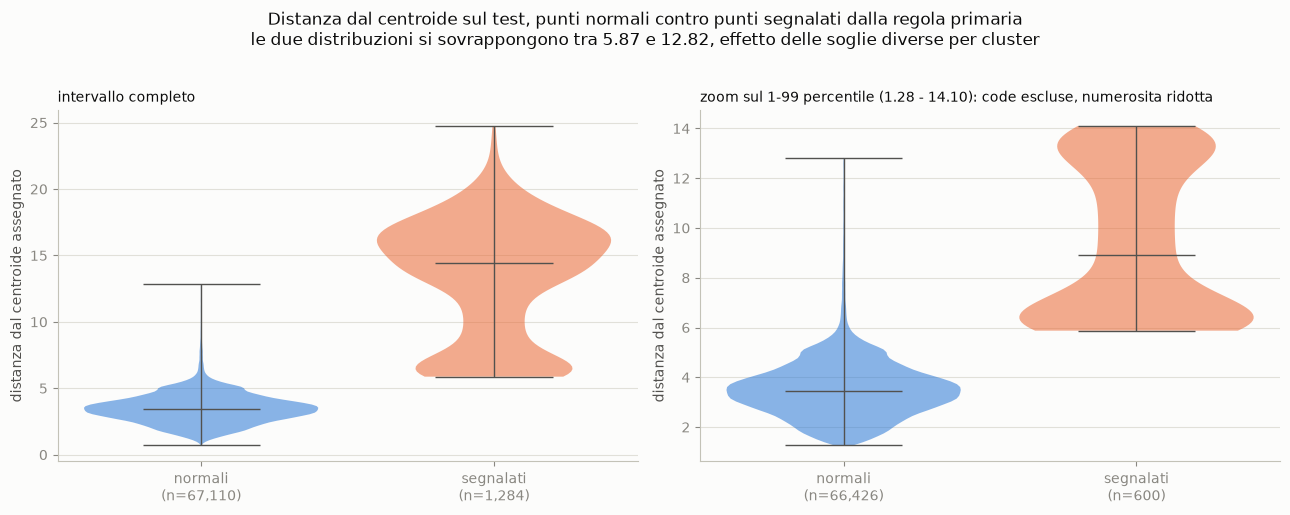

distanza minima tra i punti segnalati: 5.8740
distanza massima tra i punti normali:  12.8178
righe normali con distanza superiore alla minima segnalata: 1,645 su 67,110


In [43]:
# --- 36. Distribuzione delle distanze dal centroide: punti normali contro punti segnalati ---
dist_split = distances_by_flag(df_test_feat["dist_centroid"], df_test_feat["is_anomaly_primary"])
groups = [dist_split["normal"], dist_split["anomalous"]]
labels = [f"normali\n(n={dist_split['n_normal']:,})", f"segnalati\n(n={dist_split['n_anomalous']:,})"]

all_distances = df_test_feat["dist_centroid"].to_numpy()
low, high = np.percentile(all_distances, [1, 99])
zoom_groups = [g[(g >= low) & (g <= high)] for g in groups]

overlap_low = dist_split["anomalous"].min()
overlap_high = dist_split["normal"].max()

zoom_labels = [f"normali\n(n={len(zoom_groups[0]):,})", f"segnalati\n(n={len(zoom_groups[1]):,})"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, tick_labels, title in (
    (axes[0], groups, labels, "intervallo completo"),
    (axes[1], zoom_groups, zoom_labels,
     f"zoom sul 1-99 percentile ({low:.2f} - {high:.2f}): code escluse, numerosita ridotta"),
):
    parts = ax.violinplot(data, showmedians=True, widths=0.8)
    for body, color in zip(parts["bodies"], (COLOR_BLUE, COLOR_ORANGE)):
        body.set_facecolor(color)
        body.set_alpha(0.55)
    for key in ("cbars", "cmins", "cmaxes", "cmedians"):
        parts[key].set_color(COLOR_INK_SECONDARY)
        parts[key].set_linewidth(1.0)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(tick_labels)
    ax.set_ylabel("distanza dal centroide assegnato")
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_axisbelow(True)
    ax.grid(color=COLOR_GRID, linewidth=0.8, axis="y")

fig.suptitle(
    "Distanza dal centroide sul test, punti normali contro punti segnalati dalla regola primaria\n"
    f"le due distribuzioni si sovrappongono tra {overlap_low:.2f} e {overlap_high:.2f}, "
    "effetto delle soglie diverse per cluster",
    y=1.02,
)
fig.tight_layout()
plt.show()

print(f"distanza minima tra i punti segnalati: {overlap_low:.4f}")
print(f"distanza massima tra i punti normali:  {overlap_high:.4f}")
print(f"righe normali con distanza superiore alla minima segnalata: "
      f"{int((dist_split['normal'] > overlap_low).sum()):,} su {dist_split['n_normal']:,}")

L'ultimo grafico allarga lo sguardo dalle componenti principali ai segnali fisici di partenza. La
matrice mette a confronto a due a due quattro segnali di macchina, uno per famiglia (giri,
temperatura, vibrazione, corrente assorbita), colorando i punti del periodo storico con il cluster a
cui appartengono. Sulla diagonale ci sono le distribuzioni dei singoli segnali per cluster. Serve a
capire che cosa distingua davvero i tre stati operativi in termini leggibili da chi conosce la
macchina e non lo spazio trasformato: i cluster non sono un'etichetta astratta, corrispondono a
combinazioni riconoscibili di giri, carico termico e vibrazione.

Una avvertenza di lettura: gli assi sono lineari e una parte consistente del periodo storico ha la
macchina ferma, con giri, vibrazione e corrente praticamente a zero. Quei punti si accumulano quindi
sulle linee degli assi e schiacciano il resto della distribuzione. Non è un artefatto del grafico, è
la composizione reale del periodo: i valori stampati sotto la figura riportano il profilo mediano di
ciascun cluster calcolato su tutte le righe, non sul campione disegnato, proprio per poter leggere
quella differenza in numeri oltre che a occhio.

punti disegnati: 1,200 su 159,789 righe del periodo storico (400 per cluster, seed fisso)
segnali: rpm, temp_c, vib_rms, current_a

mediana dei segnali per cluster, su tutte le righe del periodo storico:
             rpm  temp_c  vib_rms  current_a
cluster                                     
0           0.00   18.40     0.01       0.06
1           0.00   21.60     0.01       0.06
2        1764.85   46.84     1.31      30.55

quota di righe con rpm sotto 1, macchina ferma, per cluster:
cluster
0    83.81
1    81.46
2     0.08


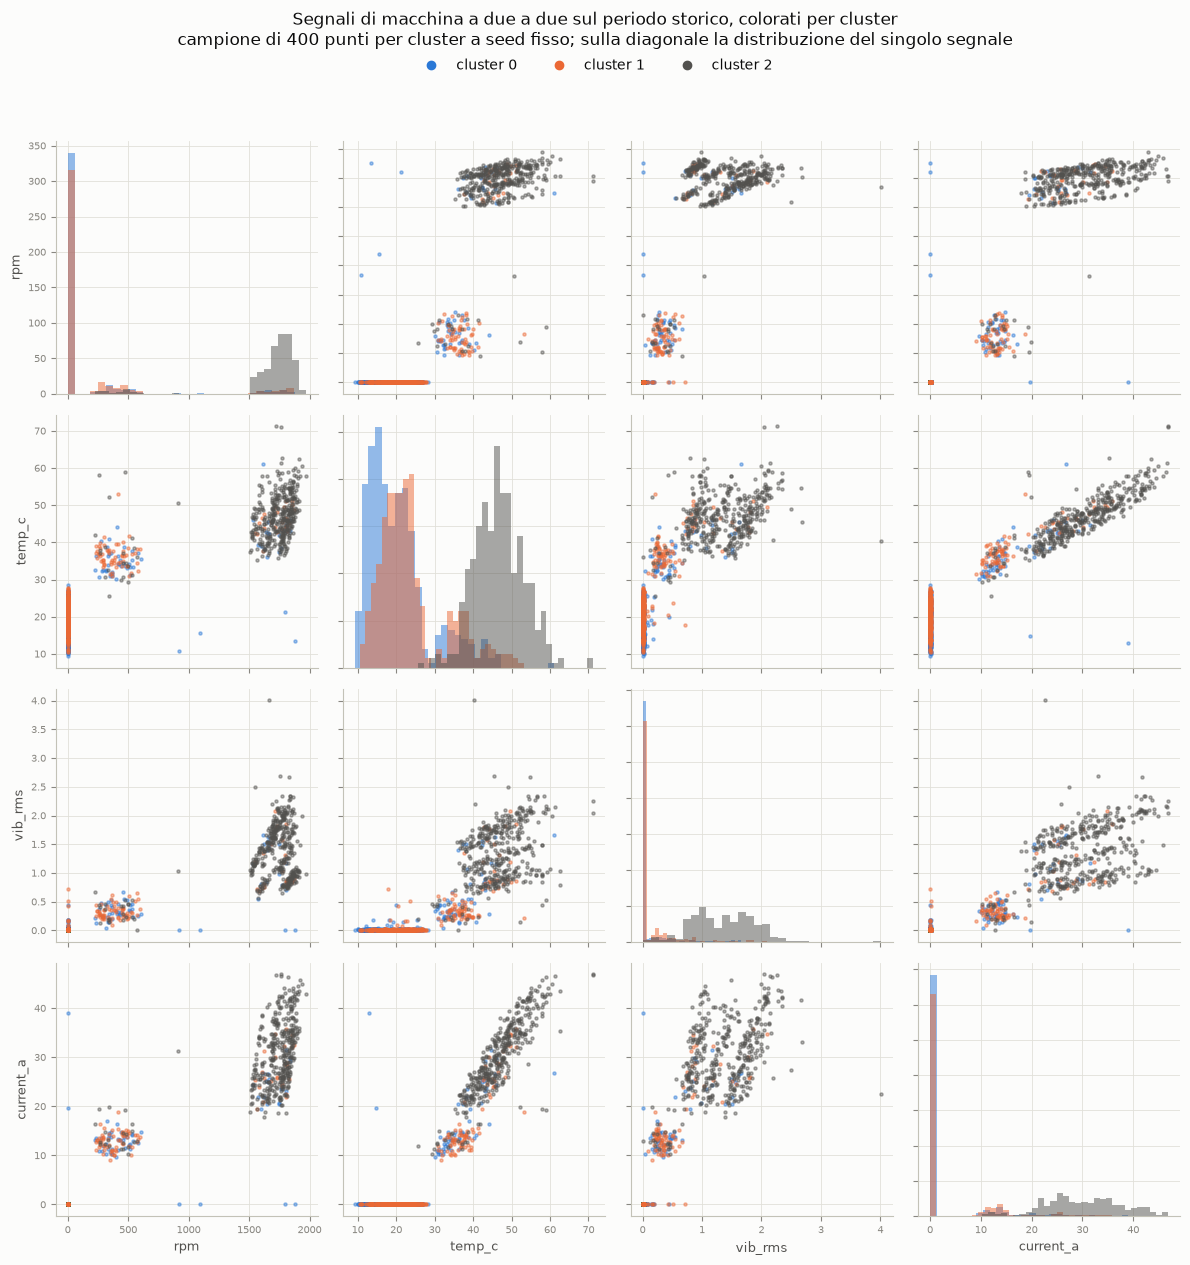

In [44]:
# --- 37. Matrice di dispersione dei principali segnali di macchina, colorata per cluster ---
PAIR_PLOT_SIZE_PER_CLUSTER = 400

pair_frame = pair_plot_frame(
    df_train_feat, feature_cols=PAIR_PLOT_SIGNALS, group_col="cluster",
    size=PAIR_PLOT_SIZE_PER_CLUSTER, seed=SEED,
)
print(f"punti disegnati: {len(pair_frame):,} su {len(df_train_feat):,} righe del periodo storico "
      f"({PAIR_PLOT_SIZE_PER_CLUSTER} per cluster, seed fisso)")
print("segnali:", ", ".join(PAIR_PLOT_SIGNALS))

# Il profilo numerico dei cluster viene calcolato su tutte le righe del periodo storico: il campione
# serve soltanto a disegnare, i valori commentati nel testo non devono dipendere da quali punti
# finiscono nella figura.
signal_profile = df_train_feat.groupby("cluster")[PAIR_PLOT_SIGNALS].median().round(2)
stopped_share = (df_train_feat.groupby("cluster")["rpm"].apply(lambda s: (s < 1).mean()) * 100).round(2)
print("\nmediana dei segnali per cluster, su tutte le righe del periodo storico:")
print(signal_profile.to_string())
print("\nquota di righe con rpm sotto 1, macchina ferma, per cluster:")
print(stopped_share.to_string())

n = len(PAIR_PLOT_SIGNALS)
fig, axes = plt.subplots(n, n, figsize=(12, 12))
clusters = sorted(pair_frame["cluster"].unique())

for i, row_col in enumerate(PAIR_PLOT_SIGNALS):
    for j, col_col in enumerate(PAIR_PLOT_SIGNALS):
        ax = axes[i, j]
        if i == j:
            for c in clusters:
                values = pair_frame.loc[pair_frame["cluster"] == c, row_col]
                ax.hist(values, bins=30, alpha=0.5, color=cluster_colors[c % len(cluster_colors)])
        else:
            for c in clusters:
                part = pair_frame[pair_frame["cluster"] == c]
                ax.scatter(part[col_col], part[row_col], s=5, alpha=0.45,
                           color=cluster_colors[c % len(cluster_colors)], rasterized=True)
        ax.set_axisbelow(True)
        ax.grid(color=COLOR_GRID, linewidth=0.6)
        ax.tick_params(labelsize=7)
        if i < n - 1:
            ax.set_xticklabels([])
        if j > 0:
            ax.set_yticklabels([])
        if j == 0:
            ax.set_ylabel(row_col, fontsize=9)
        if i == n - 1:
            ax.set_xlabel(col_col, fontsize=9)

handles = [plt.Line2D([], [], marker="o", linestyle="", color=cluster_colors[c % len(cluster_colors)],
                      label=f"cluster {c}") for c in clusters]
fig.legend(handles=handles, loc="upper center", ncol=len(clusters), frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle(
    "Segnali di macchina a due a due sul periodo storico, colorati per cluster\n"
    f"campione di {PAIR_PLOT_SIZE_PER_CLUSTER} punti per cluster a seed fisso; sulla diagonale la "
    "distribuzione del singolo segnale",
    y=1.05,
)
fig.tight_layout()
plt.show()

In [45]:
# --- 38. Riconciliazione finale: la Fase 6 non ha modificato nulla di quanto approvato prima ---
assert np.array_equal(scaler.mean_, _phase6_scaler_mean)
assert np.array_equal(pca.components_, _phase6_pca_components)
assert np.array_equal(kmeans.cluster_centers_, _phase6_kmeans_centers)
assert thresholds_p99["per_cluster_threshold"] == _phase6_thresholds
assert thresholds_p99["global_threshold"] == _phase6_global_threshold
assert np.array_equal(df_test_feat["dist_centroid"].to_numpy(), _phase6_test_distances)
assert np.array_equal(df_test_feat["is_anomaly_primary"].to_numpy(), _phase6_test_flags)

print("artefatti invariati dopo la sezione di reporting:")
print("  medie dello scaler, componenti PCA, centroidi K-Means: identici")
print(f"  soglie per cluster: " + ", ".join(f"c{c}={v:.4f}" for c, v in sorted(_phase6_thresholds.items())))
print(f"  soglia globale di confronto: {_phase6_global_threshold:.4f}")
print(f"  distanze e classificazione sul test: identiche su tutte le {len(df_test_feat):,} righe")

artefatti invariati dopo la sezione di reporting:
  medie dello scaler, componenti PCA, centroidi K-Means: identici
  soglie per cluster: c0=12.8290, c1=5.8690, c2=11.2045
  soglia globale di confronto: 8.1453
  distanze e classificazione sul test: identiche su tutte le 68,394 righe


### Sintesi finale

**Che cosa è stato costruito, e su quale assunzione.** Il sistema impara come si comporta l'impianto
nei primi sette giorni disponibili, riassume quel comportamento in tre stati ricorrenti e segnala i
momenti in cui un campione si allontana troppo dallo stato a cui è stato assegnato. L'anomalia qui
non è una proprietà assoluta della macchina: è una distanza rispetto a un periodo di riferimento
scelto. Se quel periodo cambia, o se contiene già situazioni irregolari, cambia anche ciò che il
sistema considera normale. Nel periodo storico usato per la calibrazione il 3,19% delle righe ha già
un guasto noto associato: quelle righe non sono state escluse, perché in esercizio non si saprebbe
dove sono, e il confronto diagnostico ha mostrato che la loro presenza alza le soglie in modo sensibile e
diseguale, rendendo la regola più permissiva proprio dove i guasti sono più frequenti: togliendo
dal calcolo le righe con guasto noto, la soglia globale scenderebbe da 8,1453 a 6,1053, quella del
cluster 0 si dimezzerebbe (12,8290 contro 6,4122) e quella del cluster 2 scenderebbe del 42,60%,
mentre il cluster 1 resterebbe quasi invariato.

**Che cosa sono i tre stati.** La matrice di dispersione dei segnali lo rende leggibile: il cluster 2
è la macchina in funzione, con giri intorno a 1.765, temperatura mediana 46,8 gradi, vibrazione 1,31
e corrente 30,55. I cluster 0 e 1 sono invece due varianti della macchina ferma: in entrambi giri,
vibrazione e corrente restano praticamente a zero (giri sotto 1 nell'83,81% e nell'81,46% delle
righe), e la differenza tra i due sta soprattutto nel livello termico e nelle condizioni di contesto,
non nei segnali di macchina. È un'informazione importante per interpretare tutto il resto: due terzi
della capacità descrittiva del modello sono impegnati a distinguere sfumature dello stato di riposo.

**Che cosa rileva la regola, e quanto vale.** Sul periodo di test la regola operativa, con soglie al
99esimo percentile calcolate per singolo cluster sul solo periodo storico (12,8290, 5,8690 e 11,2045),
segnala 1.284 righe su 68.394, cioè l'1,88%. Confrontata con i guasti sintetici presenti nel dataset
ottiene precisione 0,7960 e richiamo 0,2551, con F1 0,3864: quando segnala, quasi otto volte su dieci
c'è davvero un guasto noto in corso, ma di tutti i minuti di guasto ne intercetta poco più di un
quarto. Confrontata con l'annotazione parziale disponibile ottiene precisione 0,4509 e richiamo
0,2475. La lettura per evento è più incoraggiante della lettura riga per riga: dei 55 episodi di
guasto contiguo, 36 ricevono almeno una segnalazione, e l'87,69% degli alert prodotti cade entro
quindici minuti da una finestra di guasto noto dello stesso asset. Per un uso di sorveglianza conta
più accorgersi dell'episodio che marcare ogni singolo minuto.

**Sul confronto con la soglia unica.** La variante con una sola soglia globale (8,1453) ottiene su
questo test un F1 più alto su entrambi i riferimenti (0,4608 e 0,3728). Non sostituisce la regola
operativa, e il motivo non è affezione alla scelta fatta: la regola era stata fissata prima di
guardare questi numeri, sulla base di un criterio dichiarato in anticipo, cioè l'equilibrio del tasso
di allarme tra i tre cluster, che la soglia unica non garantisce (con la soglia globale un cluster
verrebbe segnalato oltre sei volte più spesso di un altro). Cambiare regola adesso, dopo aver letto le
metriche finali, significherebbe adattare il modello proprio ai dati che servono a giudicarlo, e il
risultato non sarebbe più una stima onesta. Il confronto resta però un candidato esplicito per una
revisione futura, da impostare con un proprio periodo di validazione separato.

**Dove il modello non arriva.** Il limite più netto è per tipo di guasto. L'usura del cuscinetto viene
riconosciuta nell'80,30% delle righe interessate e gli urti nel 70,00%, ma lo sbilanciamento si ferma
al 2,11% e il surriscaldamento allo 0,09%. Questi due ultimi tipi sono quasi invisibili alla logica
usata: sono derive lente e proporzionate, che spostano il punto di lavoro senza allontanarlo dal
proprio centroide quanto basta a superare la soglia. Non è un dettaglio da attenuare, è la ragione per
cui questo sistema non può essere presentato come un rilevatore di guasti completo.

**Sulla natura dei riferimenti usati.** L'annotazione `anomaly_label` copre solo una parte dei casi
positivi e non è una verità di riferimento completa: una segnalazione che non trova riscontro in
quella colonna non è per ciò stesso un errore, potrebbe essere un'anomalia reale mai annotata. Per lo
stesso motivo le due valutazioni sono state tenute separate e mai fuse in un unico numero.

**Che cosa significherebbe in esercizio.** Il volume prodotto è di circa 428 segnalazioni al giorno su
sedici asset. Se questo carico sia sostenibile non è una domanda a cui i dati possono rispondere:
dipende da quanto tempo costa esaminare una segnalazione, da quante persone se ne occupano e da quanto
costa lasciarsi sfuggire un guasto. Il numero viene quindi riportato, non giudicato accettabile.

**Come leggere i grafici di questa sezione.** Dove è stato disegnato un campione, la numerosità, la
frazione e il criterio sono scritti accanto alla figura, e il campione riguarda soltanto il disegno:
nessuna metrica di questo lavoro è calcolata su un sottoinsieme. Due avvertenze specifiche restano
importanti. Nella proiezione delle componenti principali gli alert sono tutti presenti mentre lo
sfondo è campionato, quindi la loro densità apparente è molto maggiore di quella reale. Nel confronto
tra le distribuzioni delle distanze, una parte della separazione è vera per costruzione, perché la
classe nasce dal confronto tra quella stessa distanza e la soglia; la parte informativa è la
sovrapposizione che resta, tra 5,87 e 12,82, dovuta al fatto che le soglie sono diverse per cluster.